# Solute transport: mPCN vs pCN convergence

Generate a shared-draws solute-transport dataset and compare mPCN, EP-pCN and pCNchains in the warm-up phase of the MCMC algorithm. 

Generate plots of advection matrix, solution vector and observations for the paper. 

Generate traceplots and running MSE plots for the paper, for the different observables. 

In [1]:
import os
import sys
from pathlib import Path
import json
import hashlib

import numpy as np
import matplotlib.pyplot as plt

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style

In [2]:
# Solute transport configuration
seed_data = 0
seed_mcmc = 202

# Select among predefined configurations (extend as needed)
config_id = 2  # 1=small, 2=medium, 3=extra_large, 4=baseline

configurations = {
    1: {"d": 20, "obs_highest_freq": 8, "obs_bandwidth": 5},
    2: {"d": 40, "obs_highest_freq": 12, "obs_bandwidth": 7},
    3: {"d": 60, "obs_highest_freq": 16, "obs_bandwidth": 9},
    4: {"d": 40, "obs_highest_freq": 8, "obs_bandwidth": 5},
}
if config_id not in configurations:
    raise ValueError(f"Unknown config_id: {config_id}")

selected_config = configurations[config_id]
d = selected_config["d"]
obs_highest_freq = selected_config["obs_highest_freq"]
obs_bandwidth = selected_config["obs_bandwidth"]

kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data
obs_config = 'central_modes'

print('config_id:', config_id)
print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

config_id: 2
d: 40
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
if isinstance(obs_config, dict):
    obs_config_serializable = {
        key: (val.tolist() if isinstance(val, np.ndarray) else val)
        for key, val in obs_config.items()
    }
else:
    obs_config_serializable = obs_config

data_id_config = {
    'seed_data': seed_data,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config_serializable,
    'd': d,
}
data_config = dict(data_id_config)
data_config

{'seed_data': 0,
 'kappa': 0.02,
 'sigma': 0.5,
 'alpha': 3.0,
 'gamma': 2.0,
 'tau2': 2.0,
 'a_mode': 'nearest_neighbor',
 'use_prior_A': True,
 'shared_draws_seed': 0,
 'obs_highest_freq': 12,
 'obs_bandwidth': 7,
 'obs_config': 'central_modes',
 'd': 40}

In [4]:
def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

In [5]:
# Shared-draws helpers
def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]

def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(
            f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}'
        )
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(
            d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset
        )
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }

def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }

def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [6]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
prior_diag = data['prior_diag']

print('Shared draws ready with d:', d)
print('Parameter dim:', problem.dim)
print('Initial x0 norm:', np.linalg.norm(a_init))

Shared draws ready with d: 40
Parameter dim: 780
Initial x0 norm: 0.33344310180534587


## Plot the data

Saved /home/senng/multiproposal-internal/reports/solute_transport/visual_check_A_theta_y.png


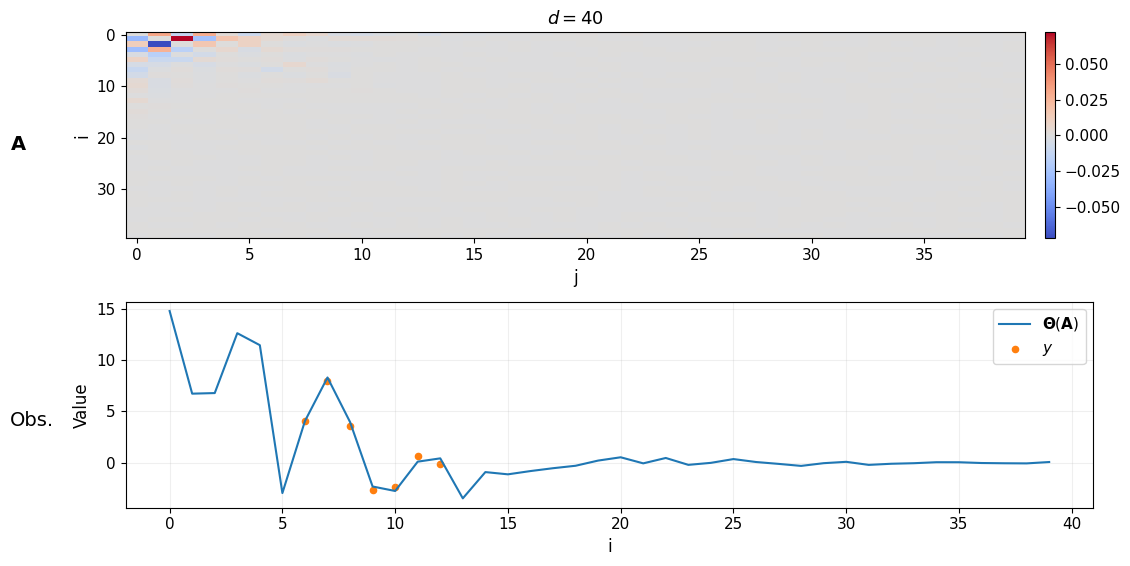

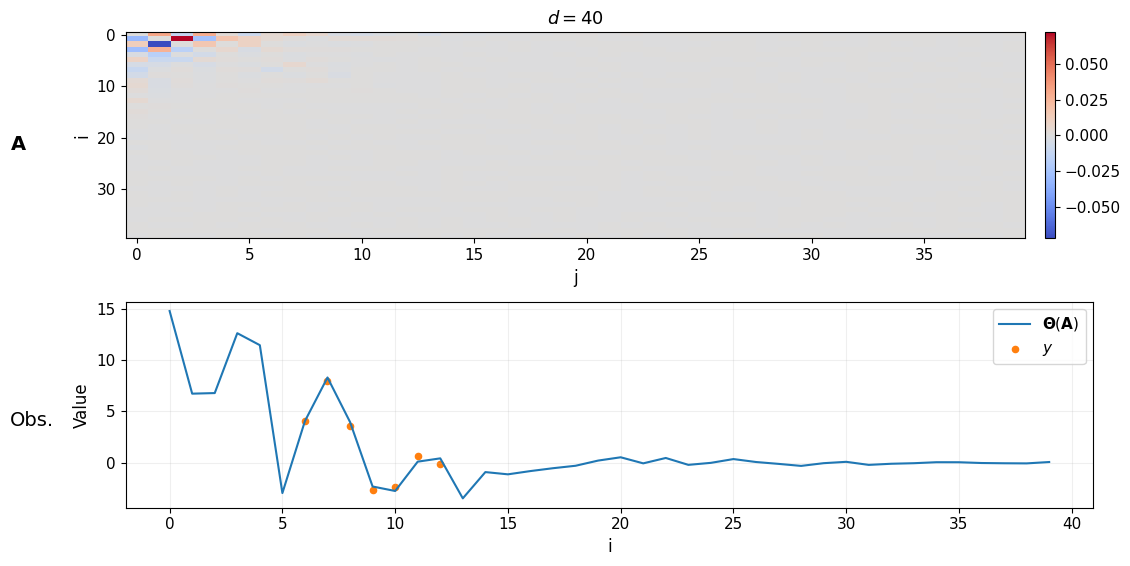

In [7]:
from multiproposal.plotting.solute_transport_convergence import plot_solute_transport_visual_check

# Visual check: A_true and observations for each d (including d_max).
plot_dims = [40]

if "reports_dir" not in globals():
    if "data_id" in globals() and "run_id" in globals():
        reports_dir = repo_root / "reports" / "solute_transport" / data_id / "fixed" / run_id
    else:
        reports_dir = repo_root / "reports" / "solute_transport"
    reports_dir.mkdir(parents=True, exist_ok=True)

plot_solute_transport_visual_check(
    plot_dims=plot_dims,
    obs_highest_freq=obs_highest_freq,
    obs_bandwidth=obs_bandwidth,
    shared_draws=shared_draws,
    seed_data=seed_data,
    reports_dir=reports_dir,
    get_obs_indices=get_obs_indices,
    generate_advection_diffusion_data_shared=generate_advection_diffusion_data_shared,
    show=True,
)

Saved /home/senng/multiproposal-internal/reports/solute_transport/visual_check_A_theta_y_examples_warmup_conv.png


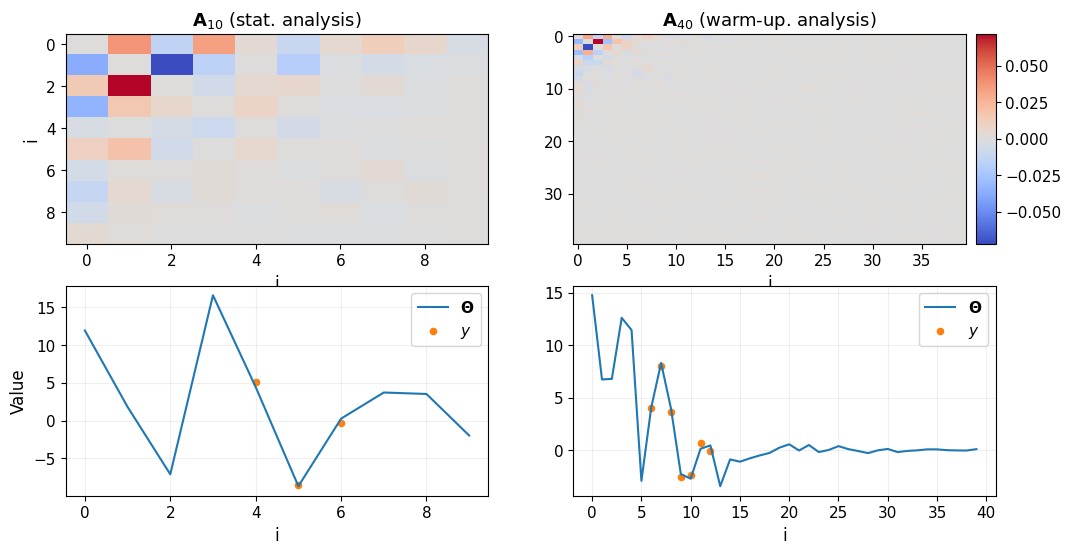

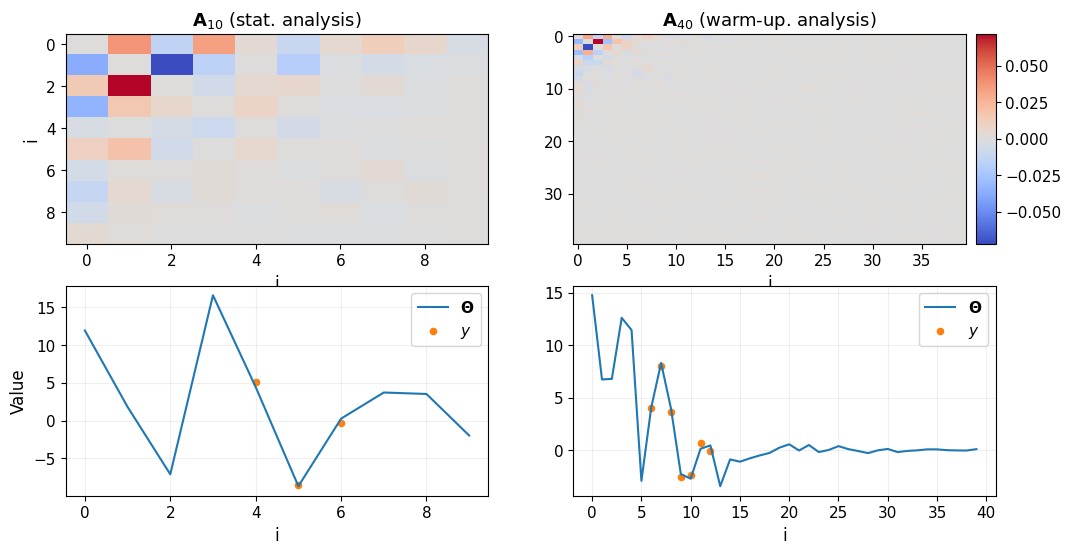

In [8]:
from multiproposal.plotting.solute_transport_convergence import plot_solute_transport_visual_check_two_setup

# Two-setup visual check: left = d=10 prior A, right = notebook config prior A
left_config = {
    'label': r"$\mathbf{A}_{10}$ (stat. analysis)",
    'd': 10,
    'obs_highest_freq': 6,
    'obs_bandwidth': 3,
    'a_mode': 'nearest_neighbor',
    'use_prior_A': True,
    'seed': seed_data,
}
right_config = {
    'label':  r"$\mathbf{A}_{40}$ (warm-up. analysis)",
    'd': d,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'seed': shared_draws_seed,
}

if "reports_dir" not in globals():
    reports_dir = repo_root / "reports" / "solute_transport"
    reports_dir.mkdir(parents=True, exist_ok=True)

plot_solute_transport_visual_check_two_setup(
    left_config=left_config,
    right_config=right_config,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    reports_dir=reports_dir,
    get_obs_indices=get_obs_indices,
    build_shared_draws=build_shared_draws,
    generate_advection_diffusion_data_shared=generate_advection_diffusion_data_shared,
    show=True,
)

## Run MCMC

This section binds the run configuration to deterministic `data_id` and `run_id` folders, then loads cached chains if available.

- Run scripts are preferred for generating chains so this notebook stays interactive.
- Chain index JSON files are used first; glob fallback is used if an index is missing.
- Keep `load_only=True` to avoid accidental reruns from the notebook.

In [9]:
# MCMC configuration
n_iters = 100000
rho = 0.9
P = 100
num_pcn_chains = 100
num_mpcn_chains = 50
burn_in = 0

load_only = True

print('n_iters:', n_iters)
print('rho:', rho)
print('P:', P)
print('num_pcn_chains:', num_pcn_chains)
print('num_mpcn_chains:', num_mpcn_chains)
print('load_only:', load_only)

n_iters: 100000
rho: 0.9
P: 100
num_pcn_chains: 100
num_mpcn_chains: 50
load_only: True


In [10]:
run_config = {
    'dataset': 'solute_transport',
    'algorithm': 'mpcn_pcn_convergence',
    'data': data_config,
    'algorithm_config': {
        'n_iters': n_iters,
        'rho': rho,
        'P': P,
        'seed_mcmc': seed_mcmc,
        'burn_in': burn_in,
        'config_id': config_id,
    },
    'execution_config': {
        'num_pcn_chains': num_pcn_chains,
        'num_mpcn_chains': num_mpcn_chains,
    },
}
# Leave overrides as None to ensure new data/run folders per config.
data_id_override = None
run_id_override = None

run_id_config = dict(run_config['algorithm_config'])
data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_pcn_convergence_h{_stable_hash(run_id_config)}"

estimations_dir = repo_root / 'estimations' / 'solute_transport' / data_id / 'fixed' / run_id
reports_dir = repo_root / 'reports' / 'solute_transport' / data_id / 'fixed' / run_id
estimations_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

config_path = estimations_dir / 'config.json'
if not config_path.exists():
    payload = dict(run_config)
    payload['data_id'] = data_id
    payload['run_id'] = run_id
    with open(config_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

print('data_id:', data_id)
print('run_id:', run_id)
print('Run directory:', estimations_dir)

data_id: data_h4afe80f670cc
run_id: mpcn_pcn_convergence_h57eaaa0da6e8
Run directory: /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8


In [11]:
rho_tag = format_float_tag(rho)
pcn_chains_dir = estimations_dir / 'chains' / 'independent_chains'
mpcn_chains_dir = estimations_dir / 'chains' / 'mpcn_independent'
pcn_chains_dir.mkdir(parents=True, exist_ok=True)
mpcn_chains_dir.mkdir(parents=True, exist_ok=True)

def pcn_chain_path(chain_idx):
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain{chain_idx:03d}.npz'

def pcn_index_path():
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_index.json'

def mpcn_chain_path(chain_idx, seed):
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed}_chain{chain_idx:03d}.npz'

def mpcn_index_path():
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed_mcmc}_index.json'

def load_index(path):
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

def load_chain(path):
    if not path.exists():
        return None
    data = np.load(path, allow_pickle=True)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    return chain, accept_rate, runtime_sec

def _indices_from_index(index_path, max_count):
    payload = load_index(index_path)
    if not payload:
        return []
    indices = []
    for entry in payload.get('chains', []):
        idx = entry.get('chain_idx')
        if isinstance(idx, (int, np.integer)) and 0 <= int(idx) < max_count:
            indices.append(int(idx))
    return sorted(set(indices))

def _indices_from_glob(chains_dir, pattern, max_count):
    indices = []
    for path in sorted(chains_dir.glob(pattern)):
        stem = path.stem
        parts = stem.split('_chain')
        if len(parts) != 2:
            continue
        try:
            idx = int(parts[1])
        except ValueError:
            continue
        if 0 <= idx < max_count:
            indices.append(idx)
    return sorted(set(indices))

In [12]:
pcn_chain_indices = _indices_from_index(pcn_index_path(), num_pcn_chains)
if not pcn_chain_indices:
    pcn_chain_indices = _indices_from_glob(
        pcn_chains_dir,
        f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain*.npz',
        num_pcn_chains,
    )

pcn_chains = []
pcn_accept_rates = []
pcn_runtimes = []
pcn_loaded_count = 0

for chain_idx in pcn_chain_indices:
    loaded = load_chain(pcn_chain_path(chain_idx))
    if loaded is None:
        continue
    chain, acc_rate, runtime_sec = loaded
    pcn_chains.append(chain)
    pcn_accept_rates.append(acc_rate)
    pcn_runtimes.append(runtime_sec)
    pcn_loaded_count += 1

if pcn_loaded_count == 0:
    print(f'No pCN chains found in {pcn_chains_dir}.')
else:
    print(f'Loaded {pcn_loaded_count} of {num_pcn_chains} pCN chains.')

Loaded 100 of 100 pCN chains.


In [13]:
mpcn_chain_indices = _indices_from_index(mpcn_index_path(), num_mpcn_chains)
if not mpcn_chain_indices:
    mpcn_chain_indices = _indices_from_glob(
        mpcn_chains_dir,
        f'mpcn_P{P}_rho{rho_tag}_seed*_chain*.npz',
        num_mpcn_chains,
    )

mpcn_chains = []
mpcn_accept_rates = []
mpcn_runtimes = []
mpcn_loaded_count = 0

for chain_idx in mpcn_chain_indices:
    seed = seed_mcmc + 5000 + chain_idx
    loaded = load_chain(mpcn_chain_path(chain_idx, seed))
    if loaded is None:
        continue
    chain, acc_rate, runtime_sec = loaded
    mpcn_chains.append(chain)
    mpcn_accept_rates.append(acc_rate)
    mpcn_runtimes.append(runtime_sec)
    mpcn_loaded_count += 1

if mpcn_loaded_count == 0:
    print(f'No mPCN chains found in {mpcn_chains_dir}.')
else:
    print(f'Loaded {mpcn_loaded_count} of {num_mpcn_chains} mPCN chains.')

Loaded 50 of 50 mPCN chains.


## Observable ID map

Use these IDs to populate `trace_observable_ids`, `pub_plot_observable_ids`, and `mse_observable_ids`.

**Parameter observables**
1. $\bar{x}_{1:d-1}$ (FirstRowMean)
2. $\mathrm{Var}(x_{1:d-1})$ (FirstRowVar)
3. $a_{01}$ (FirstComponent)
4. $\min_i x_i$ (Min)
5. $\bar{x}=\frac{1}{d}\sum_i x_i$ (Mean)
6. $\mathrm{Var}(x)$ (Variance)
7. $\|x\|_2$ (Norm)
8. $\Phi(\mathbf{A})=\frac{1}{2\sigma^2}\|y-f(\mathbf{A})\|^2$ (Potential)
9. $\sum_{j=1}^{d-1} x_{0j}$ (FirstRowSum)

**Antisymmetric matrix $\mathbf{A}$ observables**

101. $E_k(\mathbf{A})$ (BandEnergy)

102. $\max_{i<j}|a_{ij}|$ (MaxEntry)
103. $T_k(\mathbf{A})$ (TopKAvg)
104. $\|\mathbf{A}\|_2$ (SpectralNorm; skipped)
105. $S_\varepsilon(\mathbf{A})$ (Support)
106. $R_i(\mathbf{A})$ (RowNorm; set `row_index` or `row_indices`)

Before running the observable diagnostics below, verify the three inputs are loaded and consistent:
- `mpcn_chains` and `pcn_chains` for trace diagnostics.
- `pcn_chains_for_ep` for EP aggregation.
- `observable_targets` cache path and burn-in settings for running-MSE targets.

In [14]:
# MSE setup: imports and knobs
from pathlib import Path
from time import perf_counter
import gc

from multiproposal.diagnostics.observables import (
    Observable,
    make_parameter_observables,
    make_antisymmetric_A_observables,
    select_observables,
    observable_series,
 )

true_values = data.get('a_true', None)
if true_values is None:
    raise ValueError('Missing true parameter values in data.')

# Limit per-chain samples to reduce memory; set to None to load full chains.
chain_keep = 20000
burnin_true_mean = 5000

# Cache mode for posterior observable targets:
# - 'load': use only cached values and fail if anything is missing
# - 'missing': load cached values and compute only missing or forced observables
# - 'all': ignore cache contents and recompute every observable
true_observable_cache_mode = 'missing'
true_observable_force_ids = []

# A-observable hyperparameters
A_band_k = 2
A_top_k = 5
A_support_eps = 0.001
A_row_index = 0
A_use_full_row = False

# Plot selection by observable ID; set to None to plot all.
# Publication order here is: potential, first-row sum, band energy, a_{01}.
# Example: [8, 9, 101, 3]
trace_observable_ids = None
mse_observable_ids = [3, 102, 101, 8]
pub_plot_observable_ids = [3, 102, 101, 8] # [8, 9, 101, 3]

In [15]:
from multiproposal.diagnostics.running_mse import (
    load_chain_slice,
    load_pcn_replicate_chains,
    ensure_mpcn_trimmed_chains,
    load_chains_from_dir,
 )

In [16]:
# MSE setup: load pCN and pCN repilcate chains
pcn_pattern = f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain*.npz'

pcn_standard_root = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/'
    'chains/independent_chains'
 )
pcn_standard_max = 50  # Reduce memory; set to 100 if you want all chains.
pcn_chains_for_mse = load_chains_from_dir(
    pcn_standard_root, pcn_pattern, max_chains=pcn_standard_max, n_keep=chain_keep
 )
if pcn_chains_for_mse:
    print(f'Loaded {len(pcn_chains_for_mse)} pCN chains for standard estimator.')
else:
    print(f'Warning: no pCN chains found in {pcn_standard_root}.')

pcn_ep_root = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_hc6f2f62899e7/'
    'chains/independent_chains'
 )
pcn_ep_replicate_dirs = sorted([
    path for path in pcn_ep_root.glob('replicate_*') if path.is_dir()
 ])
pcn_chains_for_ep = load_pcn_replicate_chains(
    pcn_ep_replicate_dirs,
    pcn_pattern,
    chain_keep,
 )
if pcn_chains_for_ep:
    print(f'Loaded {len(pcn_chains_for_ep)} pCN replicate chains for EP estimator.')
else:
    print(f'Warning: no pCN replicate chains found in {pcn_ep_root}.')

Loaded 50 pCN chains for standard estimator.
Loaded 100 pCN replicate chains for EP estimator.


In [17]:
# MSE setup: load mPCN chains
mpcn_source_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/'
    'chains/mpcn_independent'
 )
mpcn_target_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_hc6f2f62899e7/'
    'chains/mpcn_independent'
 )
mpcn_pattern = f'mpcn_P{P}_rho{rho_tag}_seed*_chain*.npz'
ensure_mpcn_trimmed_chains(
    mpcn_source_dir,
    mpcn_target_dir,
    mpcn_pattern,
    max_chains=50,
    n_keep=chain_keep,
 )

mpcn_chains_for_mse = load_chains_from_dir(
    mpcn_target_dir,
    mpcn_pattern,
    max_chains=50,
    n_keep=chain_keep,
    exclude_substrings=('_partial',),
 )
if mpcn_chains_for_mse:
    print(f'Loaded {len(mpcn_chains_for_mse)} mPCN chains for MSE.')
if not mpcn_chains_for_mse or not pcn_chains_for_mse:
    print('Warning: missing chains for MSE computation.')

posterior_mean_chain_count = min(50, len(mpcn_chains_for_mse))

Loaded 50 mPCN chains for MSE.


In [18]:
from multiproposal.diagnostics.running_mse import (
    update_parameter_observables,
    add_first_row_sum_observable,
    update_A_observables,
    wrap_A_observables_for_params,
    select_observables_in_requested_order,
 )

# MSE setup: build base observable definitions
parameter_observables = make_parameter_observables(problem, d)
parameter_observables = update_parameter_observables(parameter_observables)

# `make_parameter_observables(...)` returns the standard parameter-space
# observables with IDs 1-8. We append one custom observable so downstream
# code can still treat all parameter observables as a single ordered list.
parameter_observables = add_first_row_sum_observable(parameter_observables, d)

A_observables_raw = make_antisymmetric_A_observables(
    k_band=A_band_k,
    top_k=A_top_k,
    eps=A_support_eps,
    row_index=A_row_index,
    full_row=A_use_full_row,
 )

# Skip the spectral norm in this notebook because it is the slowest matrix
# observable and is not part of the default figure set.
A_observables_raw = [obs for obs in A_observables_raw if obs.obs_id != 104]
A_observables_raw = update_A_observables(A_observables_raw)

A_observables = wrap_A_observables_for_params(A_observables_raw, d, make_Astar_from_atrue)
observable_defs = parameter_observables + A_observables
mse_observable_defs = observable_defs

print(f'Built {len(parameter_observables)} parameter observables and {len(A_observables)} A observables.')

Built 9 parameter observables and 5 A observables.


In [19]:
# MSE setup: select plot subsets and configure the target cache
if trace_observable_ids is None:
    trace_plot_defs = observable_defs
else:
    trace_plot_defs = select_observables(observable_defs, trace_observable_ids)

if mse_observable_ids is None:
    mse_plot_defs = mse_observable_defs
else:
    mse_plot_defs = select_observables(mse_observable_defs, mse_observable_ids)

if not trace_plot_defs:
    raise ValueError('No observables selected for traceplots.')
if not mse_plot_defs:
    raise ValueError('No observables selected for MSE plots.')

if true_observable_cache_mode not in {'load', 'missing', 'all'}:
    raise ValueError(
        "true_observable_cache_mode must be one of 'load', 'missing', or 'all'."
    )

target_metrics_dir = Path(
    '/home/senng/multiproposal-internal/estimations/solute_transport/'
    'data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics'
 )
target_metrics_dir.mkdir(parents=True, exist_ok=True)
target_metrics_path = target_metrics_dir / f'pub_observables_true_mean_rho{rho_tag}_burn{burnin_true_mean}.npz'

print(f'Target cache mode: {true_observable_cache_mode}')
print(f'Target cache path: {target_metrics_path}')

Target cache mode: missing
Target cache path: /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics/pub_observables_true_mean_rho0p90000_burn5000.npz


In [20]:
from multiproposal.diagnostics.running_mse import load_cached_observable_targets

# MSE setup: load any cached targets and decide what still needs work
cached_observable_targets = {}
if true_observable_cache_mode != 'all':
    cached_observable_targets = load_cached_observable_targets(
        target_metrics_path, observable_defs, burnin_true_mean
    )

forced_observable_ids = set(true_observable_force_ids)
forced_observable_names = {
    obs.name for obs in observable_defs if obs.obs_id in forced_observable_ids
}
missing_observable_defs = []
for obs in observable_defs:
    if true_observable_cache_mode == 'all':
        missing_observable_defs.append(obs)
    elif obs.name in forced_observable_names:
        missing_observable_defs.append(obs)
    elif obs.name not in cached_observable_targets:
        missing_observable_defs.append(obs)

if true_observable_cache_mode == 'load' and missing_observable_defs:
    raise ValueError(
        'Cache mode is set to load-only, but these observable targets are missing: '
        + ', '.join(obs.name for obs in missing_observable_defs)
    )

print(f'Loaded {len(cached_observable_targets)} cached observable targets from {target_metrics_path}.')
print(f'{len(missing_observable_defs)} observables need computation.')
if missing_observable_defs:
    print('Pending observables:', [obs.name for obs in missing_observable_defs])

Loaded 14 cached observable targets from /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics/pub_observables_true_mean_rho0p90000_burn5000.npz.
0 observables need computation.


In [21]:
from multiproposal.diagnostics.running_mse import (
    compute_single_observable_target,
    save_observable_target_cache,
 )

# MSE setup: compute missing targets, save cache, and build the final lookup
true_observable_targets = dict(cached_observable_targets)
if missing_observable_defs:
    if chain_keep is not None and chain_keep <= burnin_true_mean:
        raise ValueError('chain_keep must exceed burnin_true_mean to recompute observables.')

    load_start = perf_counter()
    mpcn_target_use = load_chains_from_dir(
        mpcn_source_dir,
        mpcn_pattern,
        max_chains=posterior_mean_chain_count,
        n_keep=chain_keep,
        exclude_substrings=('_partial',),
    )
    load_elapsed = perf_counter() - load_start
    print(
        f'Loaded {len(mpcn_target_use)} mPCN chains for target estimation in {load_elapsed:.2f}s.'
    )

    if not mpcn_target_use:
        raise ValueError('No mPCN chains available to compute true observables.')

    total_start = perf_counter()
    for obs in missing_observable_defs:
        obs_start = perf_counter()
        true_observable_targets[obs.name] = compute_single_observable_target(
            mpcn_target_use, obs, burnin_true_mean
        )
        obs_elapsed = perf_counter() - obs_start
        print(
            f'Computed target for observable {obs.obs_id} ({obs.name}) in {obs_elapsed:.2f}s.'
        )
    total_elapsed = perf_counter() - total_start
    print(f'Computed {len(missing_observable_defs)} observable targets in {total_elapsed:.2f}s.')

    save_observable_target_cache(
        target_metrics_path,
        observable_defs,
        true_observable_targets,
        burnin_true_mean,
        len(mpcn_target_use),
    )
    print(f'Saved observable target cache to {target_metrics_path}.')
else:
    print(f'Using cached targets for all {len(observable_defs)} observables.')

missing_after_compute = [
    obs.name for obs in observable_defs if obs.name not in true_observable_targets
]
if missing_after_compute:
    raise ValueError(
        'Missing cached target values for observables: ' + ', '.join(missing_after_compute)
    )

observable_targets = {
    obs.name: float(true_observable_targets[obs.name])
    for obs in observable_defs
}
true_obs_values = [observable_targets[obs.name] for obs in observable_defs]
print(f'Observable target map ready with {len(observable_targets)} entries.')

Using cached targets for all 14 observables.
Observable target map ready with 14 entries.


## Traceplots

In [20]:
# # Traceplots: mPCN (top) vs pCN (bottom) for first 3 parameters
# apply_pub_style()

# comp_list = [0, 1, 2]
# comp_list = [idx for idx in comp_list if idx < problem.dim]
# if len(comp_list) < 1:
#     raise ValueError('Need at least one component for traceplots.')

# plot_n = min(n_iters, 1000)
# mpcn_plot_count = 10
# pcn_plot_count = 10
# row_height = 1.0

# mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
# pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

# mpcn_plot_indices = list(range(mpcn_plot_count))
# pcn_plot_indices = list(range(pcn_plot_count))

# trace_series = []
# for i in mpcn_plot_indices:
#     chain_idx = mpcn_chain_indices[i] if i < len(mpcn_chain_indices) else i
#     trace_series.append((f'mPCN chain {chain_idx + 1}', mpcn_chains[i]))
# for i in pcn_plot_indices:
#     chain_idx = pcn_chain_indices[i] if i < len(pcn_chain_indices) else i
#     trace_series.append((f'pCN chain {chain_idx + 1}', pcn_chains[i]))

# true_values = data.get('a_true', None)

# nrows = len(trace_series)
# ncols = len(comp_list)
# fig, axes = plt.subplots(
#     nrows,
#     ncols,
#     figsize=(4.2 * ncols, row_height * nrows),
#     sharex=True,
#     sharey='col',
# )
# if nrows == 1:
#     axes = np.array([axes])
# if ncols == 1:
#     axes = axes[:, None]

# for row_idx, (label, chain) in enumerate(trace_series):
#     post_chain = chain[:plot_n]
#     for col_idx, comp in enumerate(comp_list):
#         ax = axes[row_idx, col_idx]
#         ax.plot(post_chain[:, comp], linewidth=0.6, color='tab:blue')
#         if true_values is not None:
#             ax.axhline(
#                 true_values[comp],
#                 color='black',
#                 linestyle=':',
#                 linewidth=0.8,
#             )
#         if row_idx == 0:
#             ax.set_title(f'Component {comp}')
#         if col_idx == 0:
#             ax.set_ylabel(label, rotation=0, labelpad=40, va='center')
#         ax.grid(alpha=0.2)

# for ax in axes[-1, :]:
#     ax.set_xlabel('Iteration')

# fig.suptitle('Traceplots: mPCN (top) vs pCN (bottom)')
# fig.tight_layout()
# fig.savefig(
#     reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

In [21]:
# # Overlayed traceplots: all mPCN together and all pCN together (grouped by observable)
# apply_pub_style()

# comp_list = [0, 1, 40, 779]
# comp_list = [idx for idx in comp_list if idx < problem.dim]
# if len(comp_list) < 1:
#     raise ValueError('Need at least one component for traceplots.')

# plot_n = min(n_iters, 100)
# mpcn_plot_count = 50
# pcn_plot_count = 50
# mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
# pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

# mpcn_plot_indices = list(range(mpcn_plot_count))
# pcn_plot_indices = list(range(pcn_plot_count))

# mpcn_stack = np.stack([mpcn_chains[i][:plot_n] for i in mpcn_plot_indices], axis=0)
# pcn_stack = np.stack([pcn_chains[i][:plot_n] for i in pcn_plot_indices], axis=0)
# mpcn_mean = np.mean(mpcn_stack, axis=0)
# pcn_mean = np.mean(pcn_stack, axis=0)

# alg_defs = [
#     ('mPCN', mpcn_stack, mpcn_mean),
#     ('pCN', pcn_stack, pcn_mean),
# ]

# chain_color = '0.65'
# mean_color = '0.0'
# chain_linewidth = 0.6
# mean_linewidth = 2.0

# nrows = len(comp_list)
# ncols = 2
# fig, axes = plt.subplots(
#     nrows,
#     ncols,
#     figsize=(8.4, 2.2 * nrows),
#     sharex=True,
#     sharey='row',
# )
# if nrows == 1:
#     axes = np.array([axes])

# for row_idx, comp in enumerate(comp_list):
#     obs_label = rf"$x_{{{comp}}}$"
#     for col_idx, (label, stack, mean_chain) in enumerate(alg_defs):
#         ax = axes[row_idx, col_idx]
#         for chain_idx in range(stack.shape[0]):
#             ax.plot(
#                 stack[chain_idx, :, comp],
#                 linewidth=chain_linewidth,
#                 color=chain_color,
#                 alpha=0.35,
#             )
#         ax.plot(mean_chain[:, comp], linewidth=mean_linewidth, color=mean_color)
#         if col_idx == 0:
#             ax.set_ylabel(obs_label, rotation=0, labelpad=32, va='center')
#         ax.grid(alpha=0.2)

# for col_idx, (label, _, _) in enumerate(alg_defs):
#     axes[0, col_idx].set_title(label)

# for ax in axes[-1, :]:
#     ax.set_xlabel('Iteration')

# fig.tight_layout()
# fig.savefig(
#     reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_overlay_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

In [22]:
# # Overlayed traceplots for additional observables
# apply_pub_style()

# from multiproposal.diagnostics.observables import stack_observable_series

# plot_n = min(n_iters, 100)
# mpcn_plot_count = 50
# pcn_plot_count = 50
# mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
# pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

# mpcn_plot_indices = list(range(mpcn_plot_count))
# pcn_plot_indices = list(range(pcn_plot_count))

# mpcn_chains_plot = [mpcn_chains[i][:plot_n] for i in mpcn_plot_indices]
# pcn_chains_plot = [pcn_chains[i][:plot_n] for i in pcn_plot_indices]

# chain_color = '0.65'
# mean_color = '0.0'
# chain_linewidth = 0.6
# mean_linewidth = 2.0

# observables_to_plot = trace_plot_defs
# if not observables_to_plot:
#     raise ValueError('No observables selected for plotting.')

# n_obs = len(observables_to_plot)
# nrows = int(np.ceil(n_obs / 2))
# fig, axes = plt.subplots(nrows, 4, figsize=(16.0, 2.8 * nrows), sharex=True, sharey='row')
# if nrows == 1:
#     axes = axes[None, :]

# col_titles = ['mPCN', 'pCN', 'mPCN', 'pCN']
# for col_idx, title in enumerate(col_titles):
#     fig.text((col_idx + 0.5) / 4.0, 0.995, title, ha='center', va='top', fontsize=10)

# for obs_idx, obs in enumerate(observables_to_plot):
#     row_idx = obs_idx // 2
#     block_idx = obs_idx % 2
#     col0 = block_idx * 2
#     col1 = col0 + 1

#     mpcn_obs = stack_observable_series(mpcn_chains_plot, obs)
#     pcn_obs = stack_observable_series(pcn_chains_plot, obs)
#     mpcn_mean = np.mean(mpcn_obs, axis=0)
#     pcn_mean = np.mean(pcn_obs, axis=0)

#     ax_m = axes[row_idx, col0]
#     ax_p = axes[row_idx, col1]

#     for chain_idx in range(mpcn_obs.shape[0]):
#         ax_m.plot(
#             mpcn_obs[chain_idx],
#             linewidth=chain_linewidth,
#             color=chain_color,
#             alpha=0.35,
#         )
#     ax_m.plot(mpcn_mean, linewidth=mean_linewidth, color=mean_color)
#     ax_m.set_title(obs.label)
#     ax_m.grid(alpha=0.2)

#     for chain_idx in range(pcn_obs.shape[0]):
#         ax_p.plot(
#             pcn_obs[chain_idx],
#             linewidth=chain_linewidth,
#             color=chain_color,
#             alpha=0.35,
#         )
#     ax_p.plot(pcn_mean, linewidth=mean_linewidth, color=mean_color)
#     ax_p.set_title(obs.label)
#     ax_p.grid(alpha=0.2)

# if n_obs % 2 == 1:
#     for ax in axes[-1, 2:4]:
#         ax.set_visible(False)

# for ax in axes[-1, :]:
#     if ax.get_visible():
#         ax.set_xlabel('Iteration')

# fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.965))
# fig.savefig(
#     reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_observables_rho{rho_tag}.png',
#     bbox_inches='tight',
# )
# plt.show()

/home/senng/multiproposal-internal/src/multiproposal/plotting/solute_transport_convergence.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))


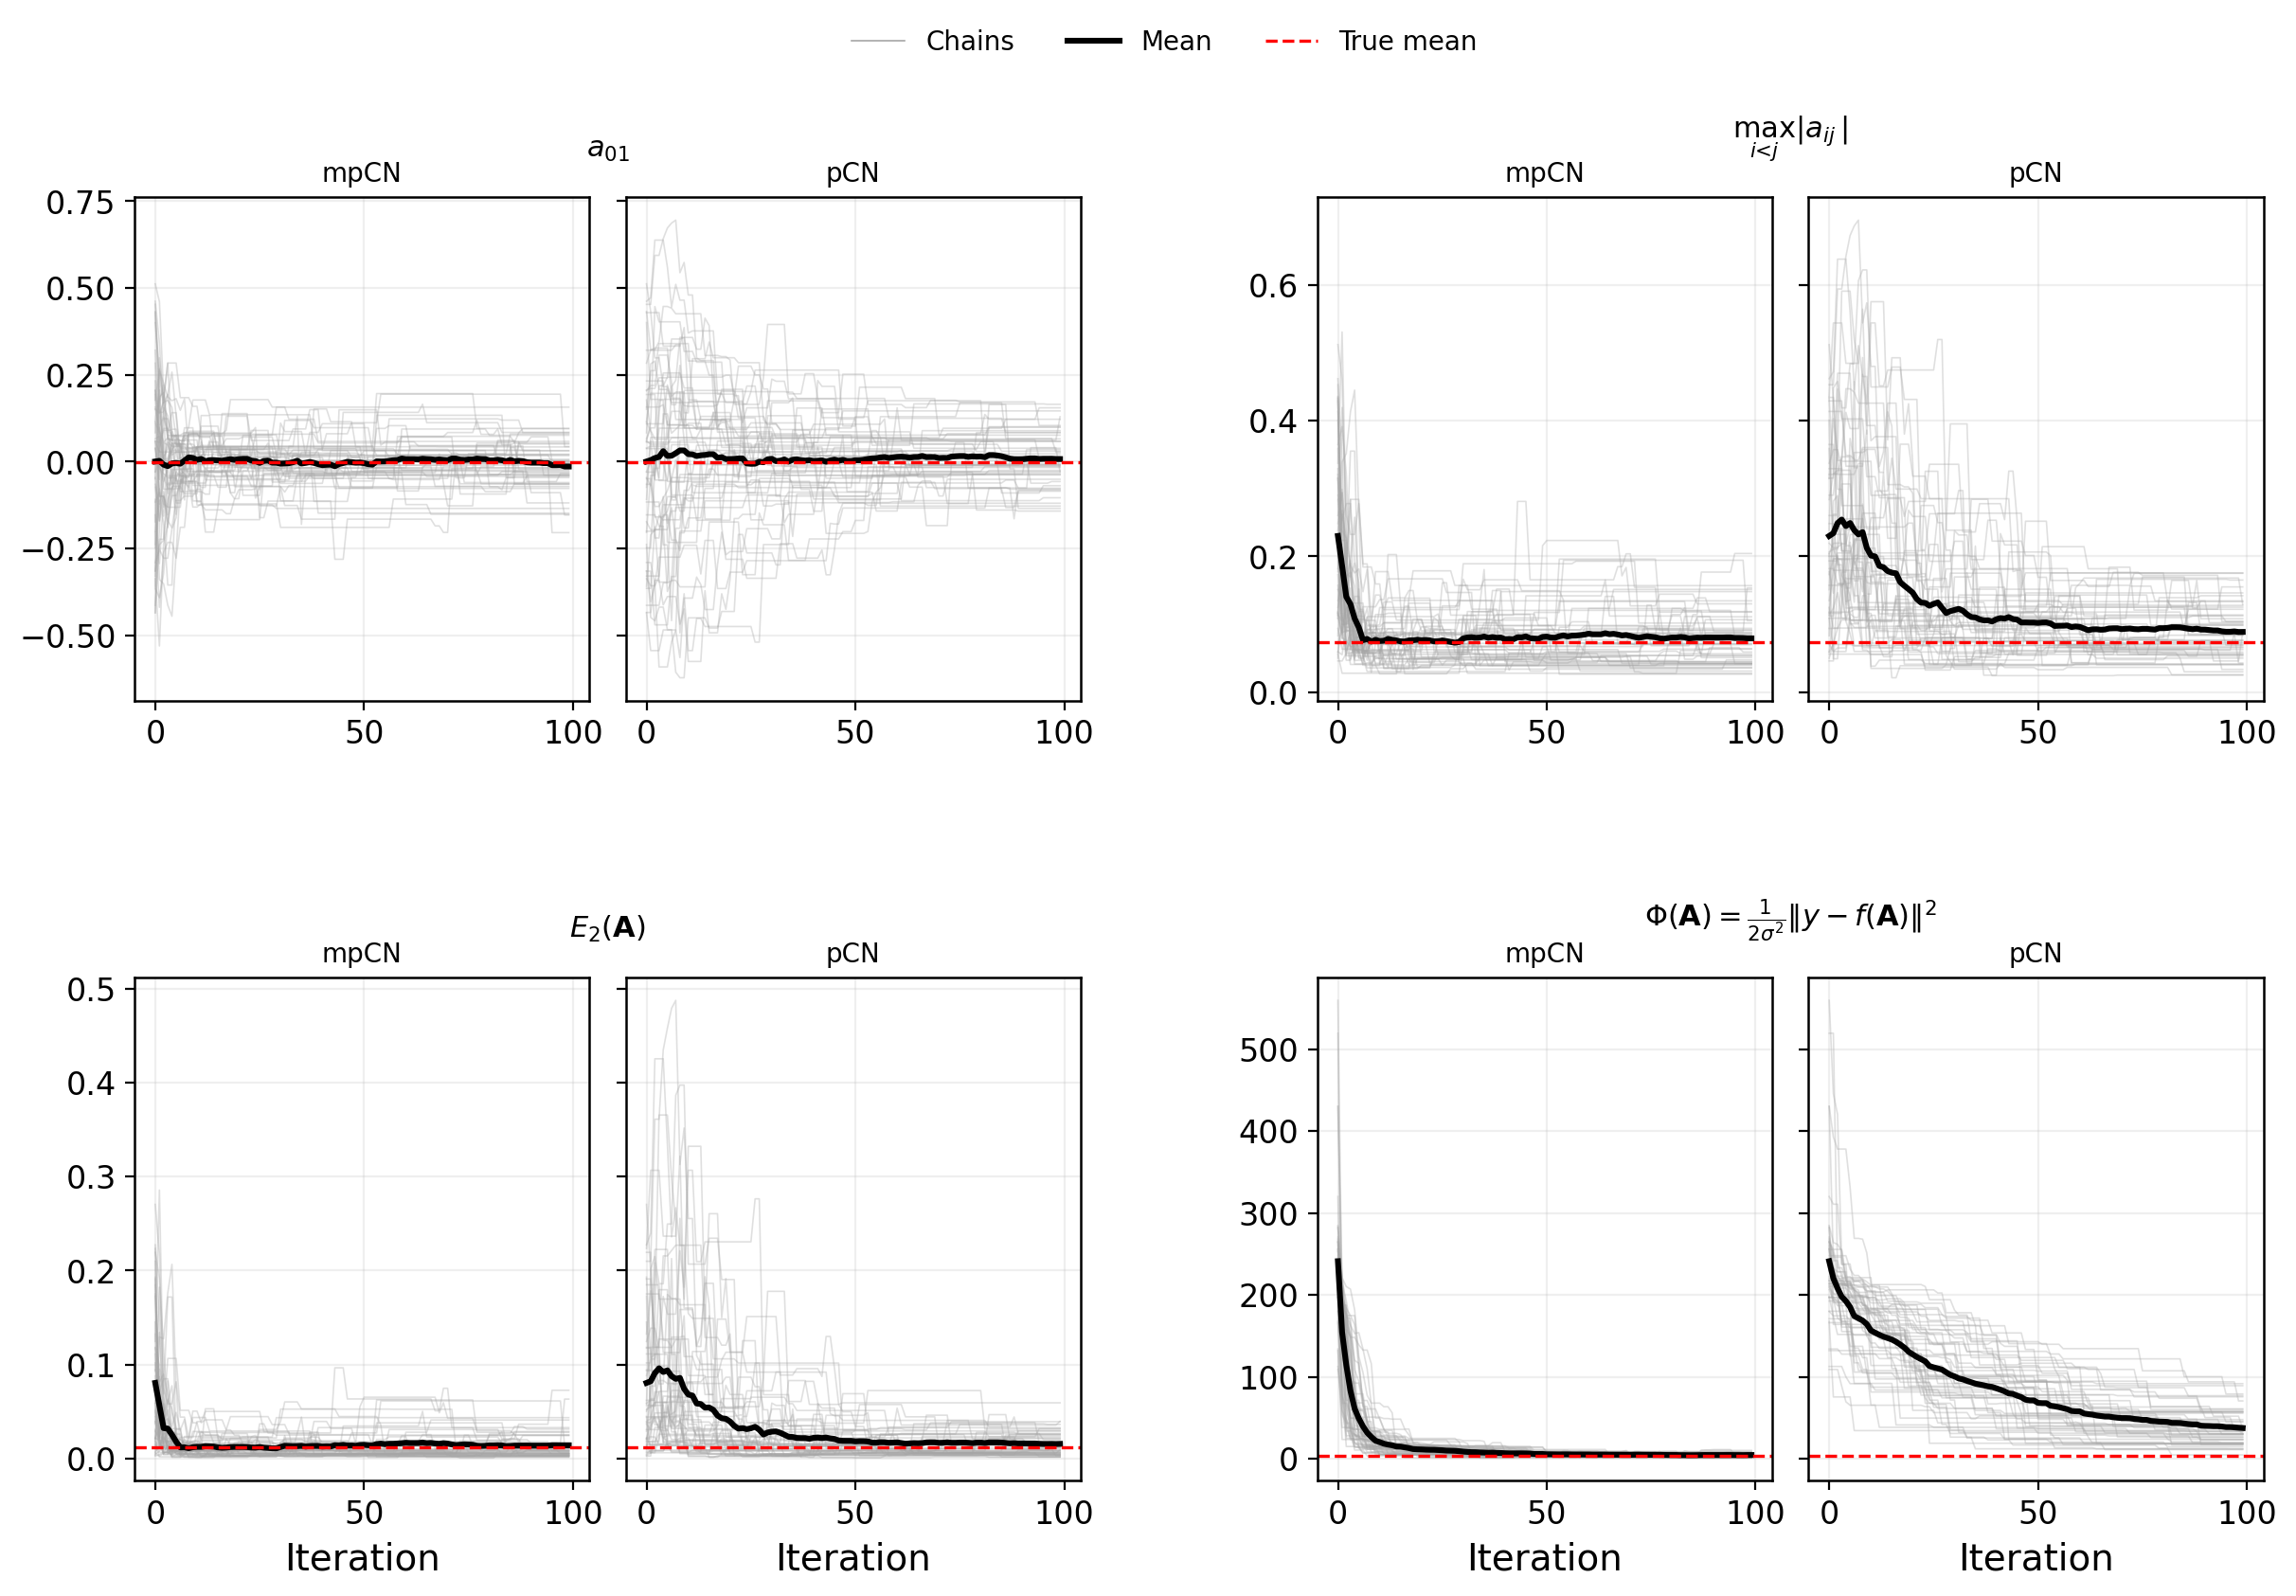

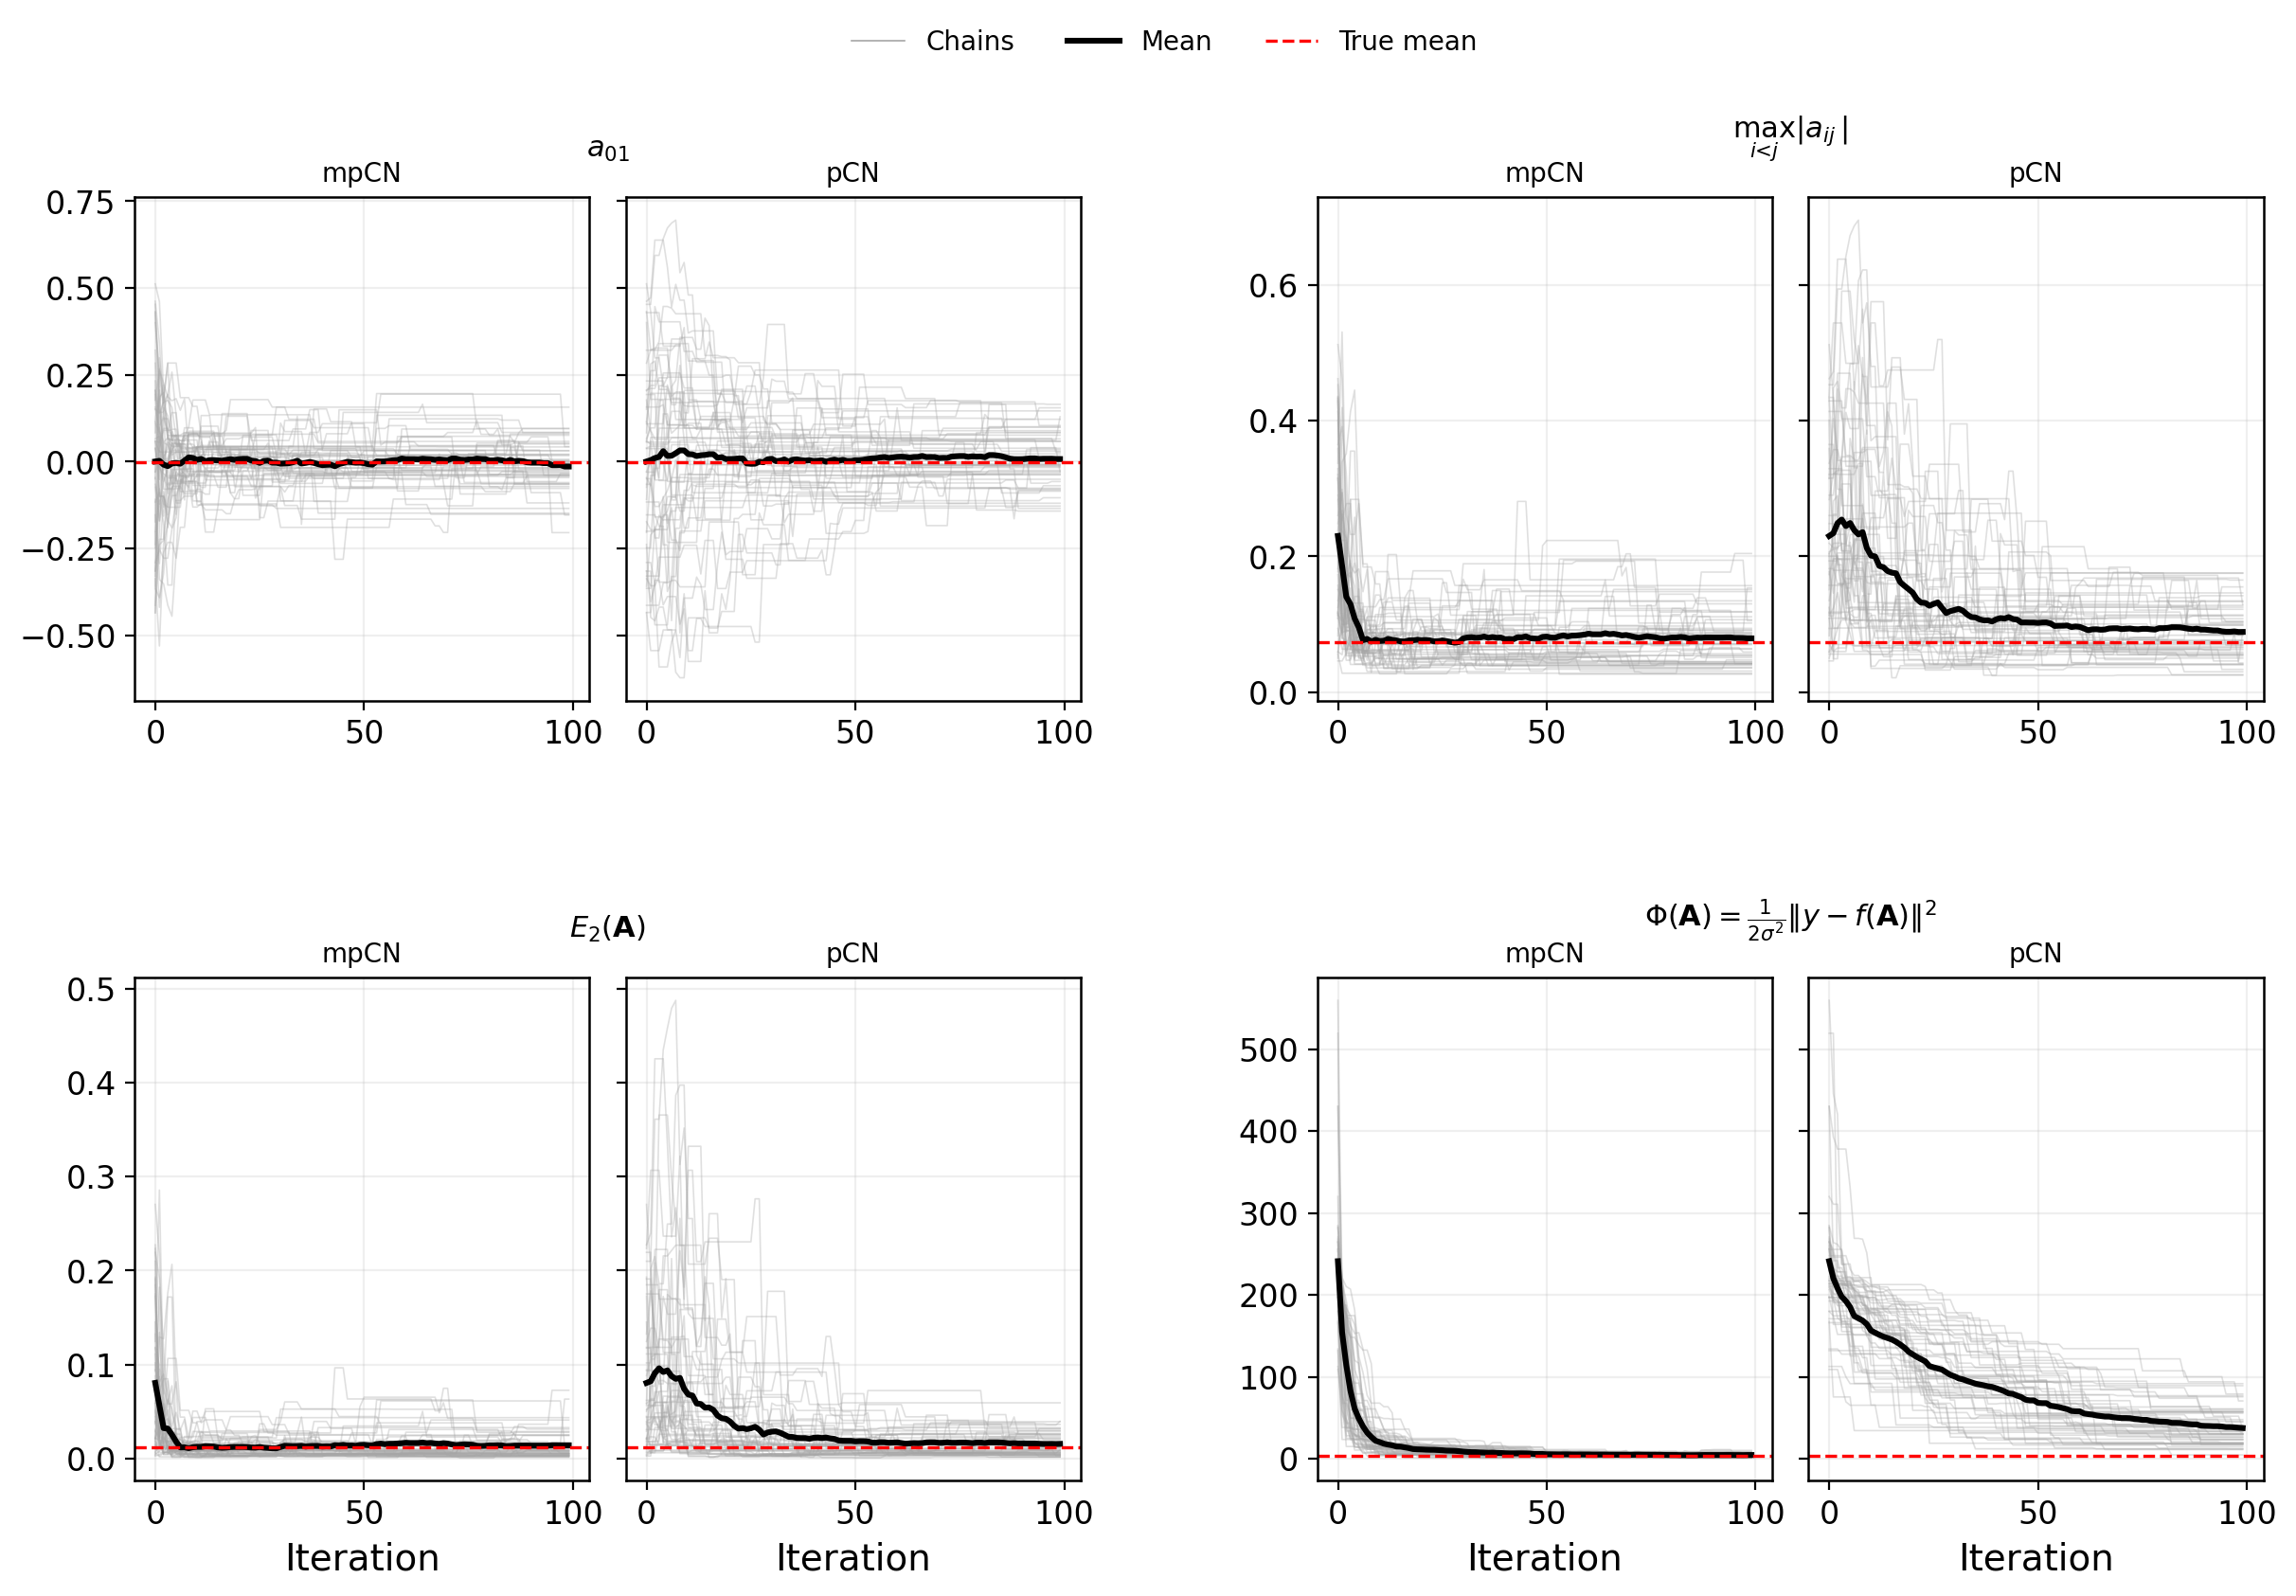

In [22]:
from multiproposal.plotting.solute_transport_convergence import plot_solute_transport_pub_traceplots

# Publication-quality observables traceplots: all mPCN together and all pCN together (grouped by observable)
plot_solute_transport_pub_traceplots(
    mpcn_chains=mpcn_chains,
    pcn_chains=pcn_chains,
    observable_defs=observable_defs,
    observable_targets=observable_targets,
    pub_plot_observable_ids=pub_plot_observable_ids,
    reports_dir=reports_dir,
    rho_tag=rho_tag,
    n_iters=n_iters,
    show=True,
)

/home/senng/multiproposal-internal/src/multiproposal/plotting/solute_transport_convergence.py:481: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))


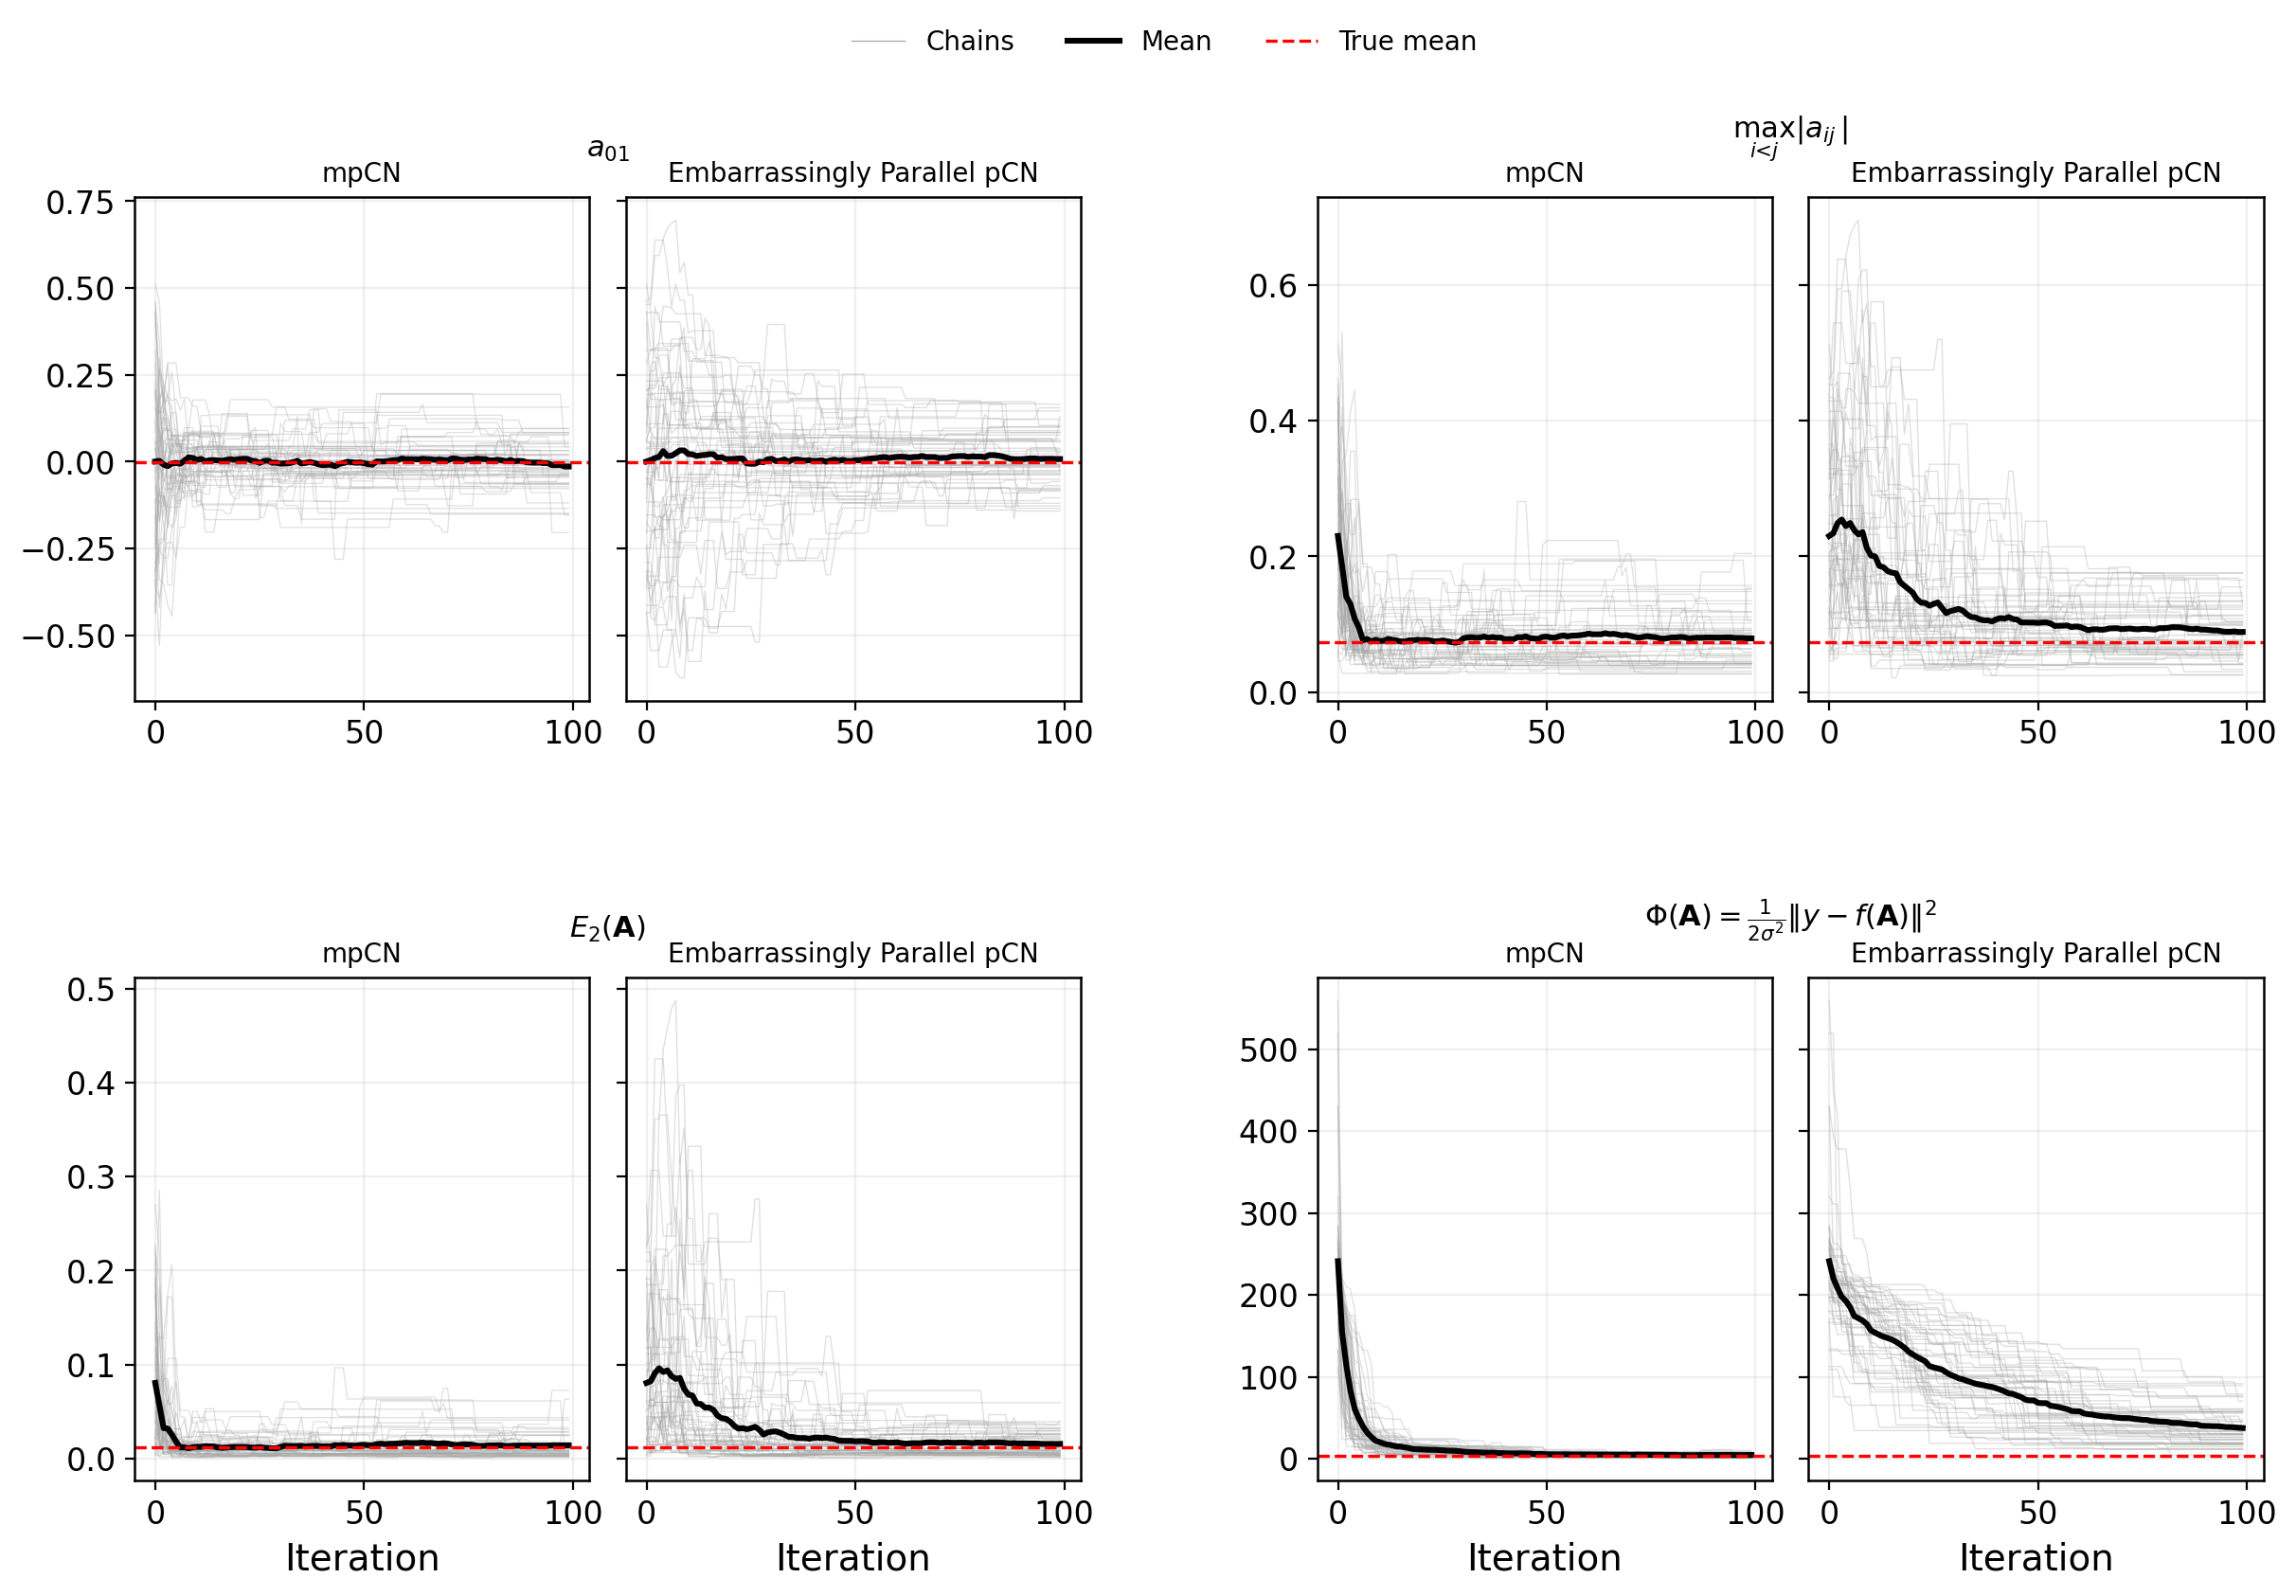

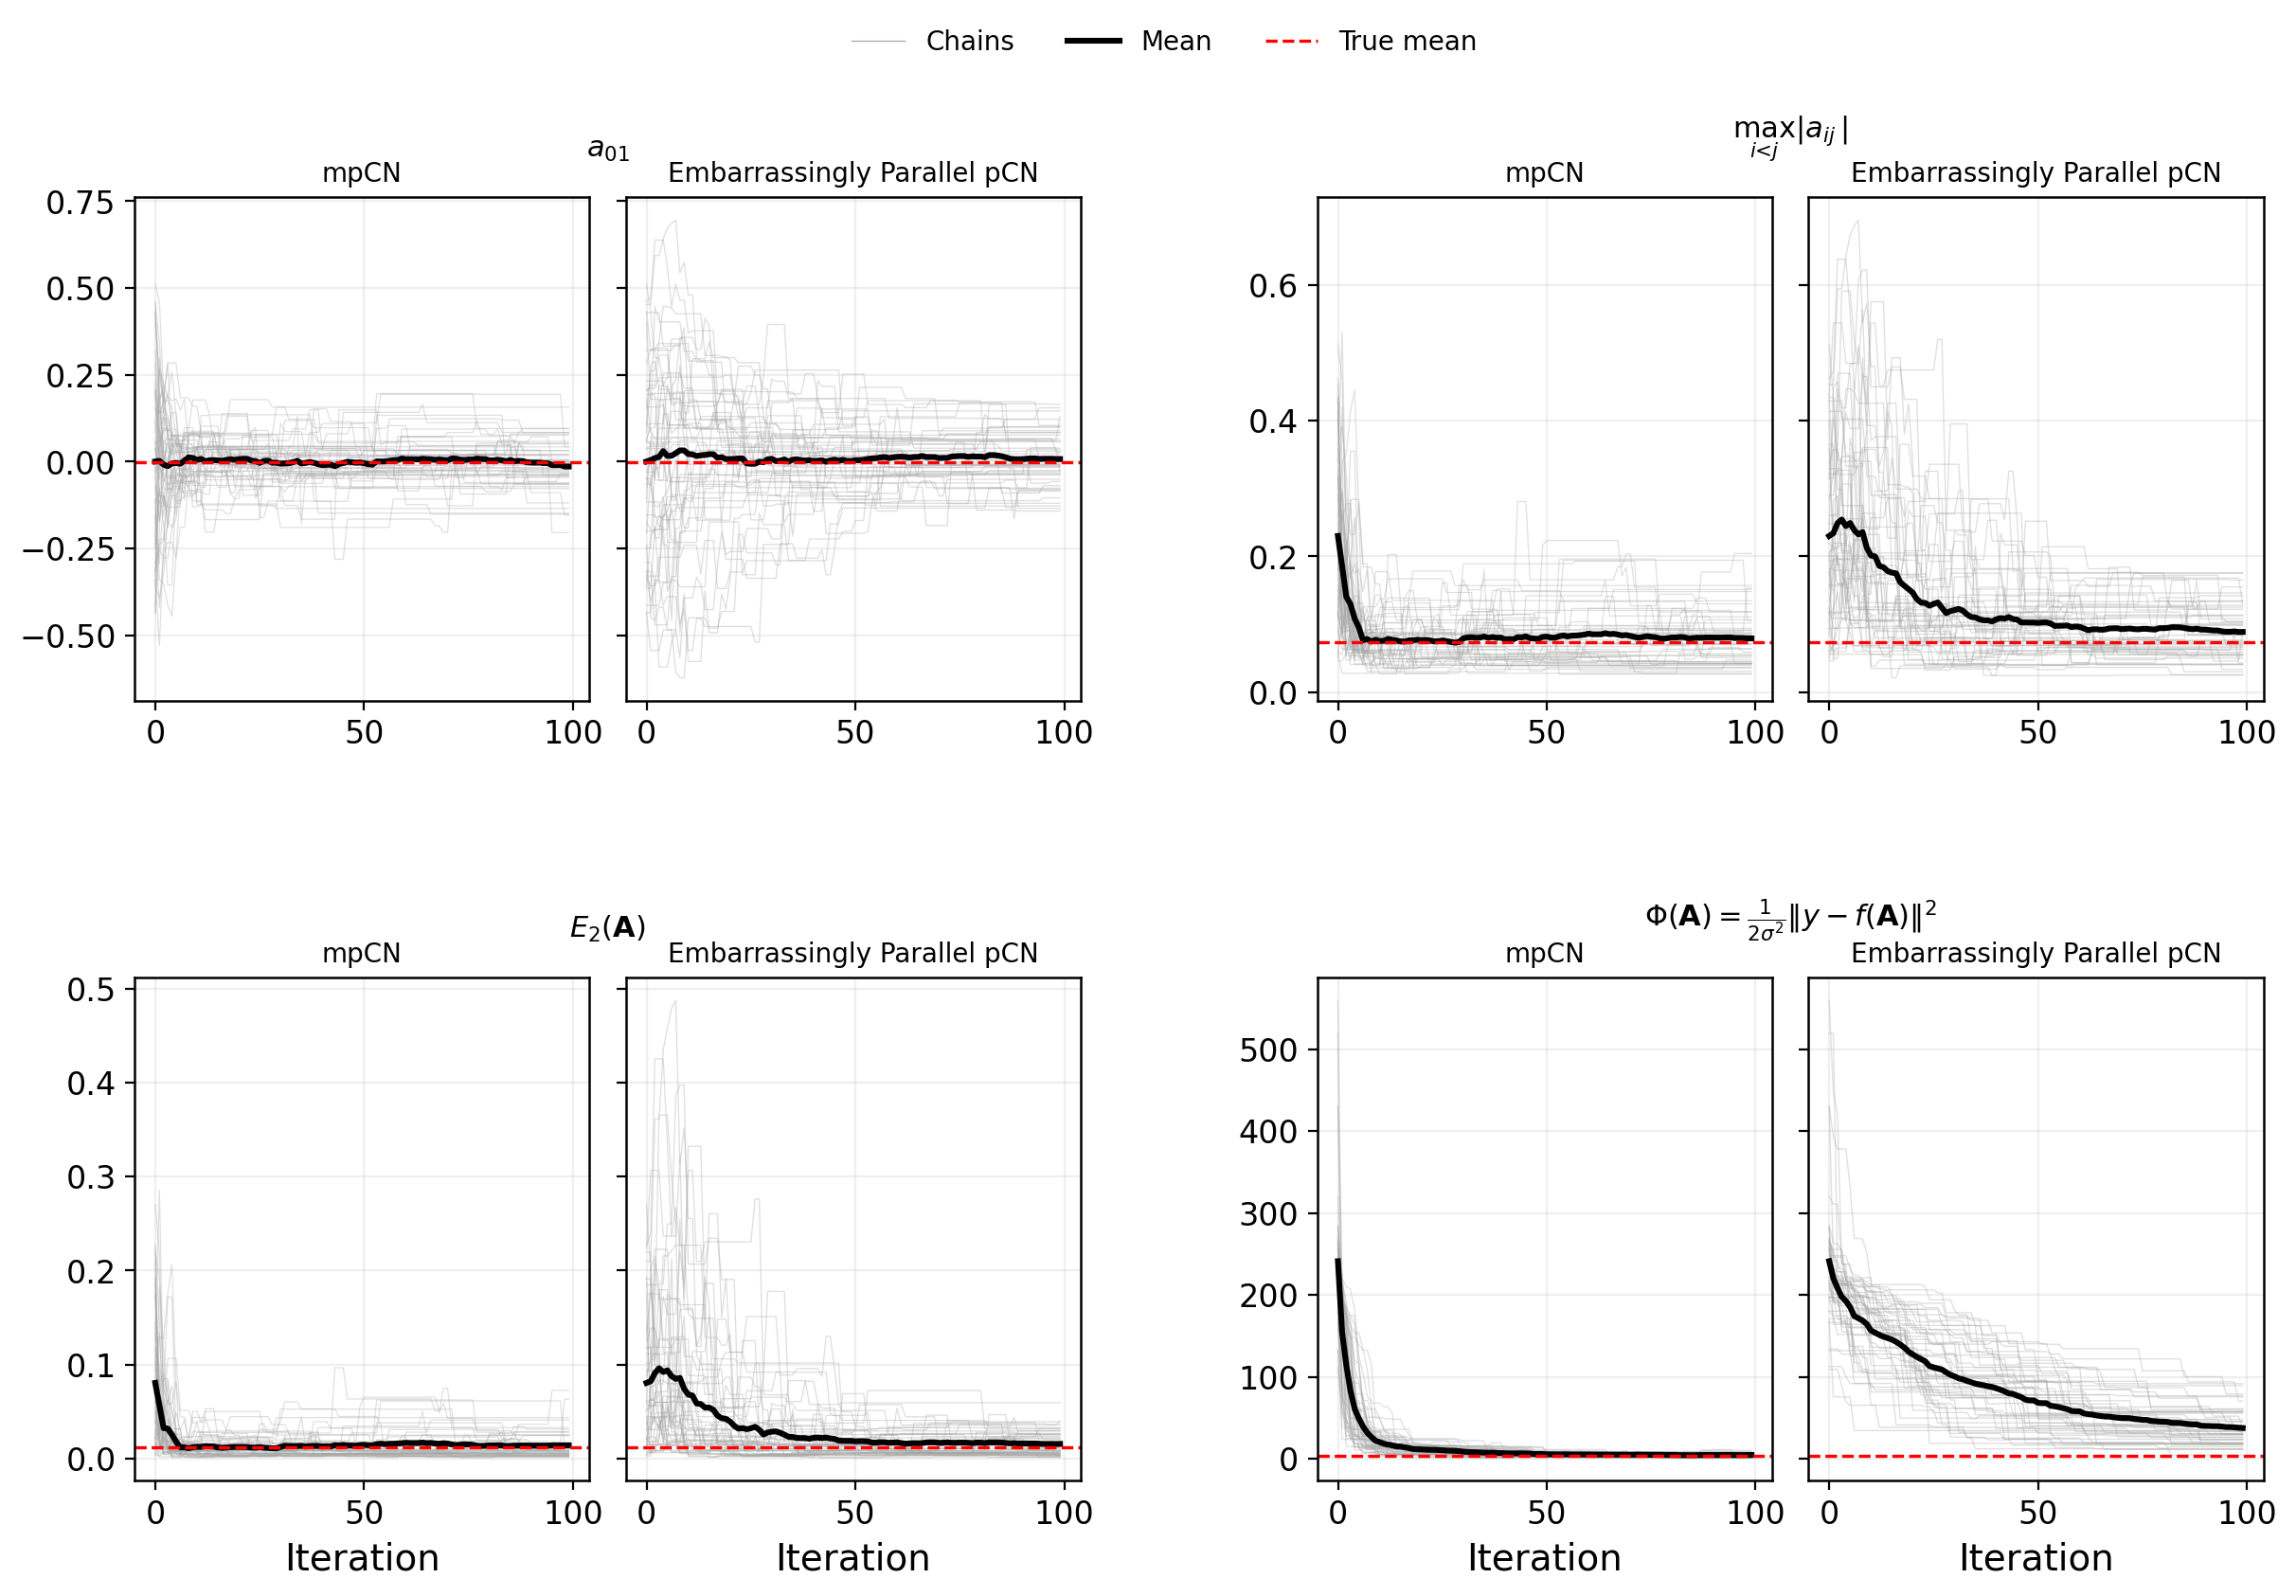

In [23]:
from multiproposal.plotting.solute_transport_convergence import plot_solute_transport_pub_traceplots_ep

# Publication-quality observables traceplots: mPCN chains vs EP-replicate pCN chains
plot_solute_transport_pub_traceplots_ep(
    mpcn_chains=mpcn_chains,
    pcn_chains_for_ep=pcn_chains_for_ep,
    P=P,
    observable_defs=observable_defs,
    observable_targets=observable_targets,
    pub_plot_observable_ids=pub_plot_observable_ids,
    reports_dir=reports_dir,
    rho_tag=rho_tag,
    n_iters=n_iters,
    show=True,
)

## Autocorrelation of chains

Compute per-component ACF using statsmodels and average across components to get one ACF per chain.
Plots show selected chain ACFs and the average ACF across the first N chains.

In [25]:
# from multiproposal.plotting.autocorrelation import (
#     compute_acf_matrices_with_cache,
#     plot_acf_comparison_grid,
#     plot_acf_overlay,
#  )

# acf_max_lag = 200
# burnin_acf = 1000
# num_acf_pcn_chains = 100
# pcn_acf_indices = list(range(min(num_acf_pcn_chains, len(pcn_chains))))
# num_acf_mpcn_chains = 16
# mpcn_acf_indices = list(range(min(num_acf_mpcn_chains, len(mpcn_chains))))
# refresh_acf_metrics = False

# acf_metrics_dir = estimations_dir / 'metrics' / 'acf'
# acf_metrics_dir.mkdir(parents=True, exist_ok=True)
# pcn_acf_path = acf_metrics_dir / f'pcn_acf_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{burnin_acf}.npz'
# mpcn_acf_path = acf_metrics_dir / f'mpcn_acf_P{P}_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{burnin_acf}.npz'
# pcn_thin_burnin = burnin_acf // P
# pcn_thin_acf_path = acf_metrics_dir / (
#     f'pcn_acf_thinP{P}_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{pcn_thin_burnin}.npz'
#  )

# acf_matrices = compute_acf_matrices_with_cache(
#     pcn_chains=pcn_chains,
#     mpcn_chains=mpcn_chains,
#     max_lag=acf_max_lag,
#     burn_in=burnin_acf,
#     pcn_acf_path=pcn_acf_path,
#     mpcn_acf_path=mpcn_acf_path,
#     pcn_thin_acf_path=pcn_thin_acf_path,
#     thin_stride=P,
#     refresh=refresh_acf_metrics,
#  )

# pcn_acf_matrix = acf_matrices['pcn']
# mpcn_acf_matrix = acf_matrices['mpcn']
# pcn_thin_acf_matrix = acf_matrices['pcn_thin']

# acf_plot_results = plot_acf_comparison_grid(
#     mpcn_acf_matrix=mpcn_acf_matrix,
#     pcn_acf_matrix=pcn_acf_matrix,
#     pcn_thin_acf_matrix=pcn_thin_acf_matrix,
#     mpcn_acf_indices=mpcn_acf_indices,
#     pcn_acf_indices=pcn_acf_indices,
#     P=P,
#     reports_dir=reports_dir,
#     rho_tag=rho_tag,
#     show=True,
# )
# lag_grid = acf_plot_results['lag_grid']
# mpcn_acf_mean = acf_plot_results['mpcn_mean']
# pcn_acf_mean = acf_plot_results['pcn_mean']
# pcn_thin_acf_mean = acf_plot_results['pcn_thin_mean']

In [26]:
# plot_acf_overlay(
#     lag_grid=lag_grid,
#     mpcn_acf_mean=mpcn_acf_mean,
#     pcn_acf_mean=pcn_acf_mean,
#     pcn_thin_acf_mean=pcn_thin_acf_mean,
#     P=P,
#     reports_dir=reports_dir,
#     rho_tag=rho_tag,
#     show=True,
# )

## Running MSE for observables

Compute running MSE for the observables using mPCN, pCN, and EP estimators.

Running-MSE workflow in this notebook:
- Select observable IDs and load cached targets if they exist.
- Compute only missing series, then update the cache file.
- Plot the selected observables using the same iteration grid for all estimators.

In [27]:
# Running MSE: configure requested observables and cache behavior
from multiproposal.diagnostics.observables import compute_running_mse, min_chain_len
from multiproposal.diagnostics.running_mse import select_observables_in_requested_order

nr_replicates = 50
max_iter_mse = 1000

mpcn_reps = min(nr_replicates, len(mpcn_chains_for_mse))
pcn_reps = min(nr_replicates, len(pcn_chains_for_mse))
if mpcn_reps < 1 or pcn_reps < 1:
    raise ValueError('Need at least one mPCN and one pCN chain for MSE plots.')

effective_P = min(P, len(pcn_chains_for_ep))
if effective_P < 1:
    print('Warning: no pCN chains available for EP estimator; EP curve will be skipped.')
ep_group_count = 0
if effective_P > 0:
    ep_group_count = min(nr_replicates, len(pcn_chains_for_ep) // effective_P)
    if ep_group_count < 1:
        print('Warning: not enough pCN chains for EP estimator; EP curve will be skipped.')

mpcn_use = mpcn_chains_for_mse[:mpcn_reps]
pcn_use = pcn_chains_for_mse[:pcn_reps]
ep_groups = []
if ep_group_count > 0:
    ep_groups = [
        pcn_chains_for_ep[i * effective_P : (i + 1) * effective_P]
        for i in range(ep_group_count)
    ]

min_len_mpcn = min_chain_len(mpcn_use)
min_len_pcn = min_chain_len(pcn_use)
min_len_ep = None
if ep_groups:
    min_len_ep = min(min_chain_len(group) for group in ep_groups)

n_iter = min(
    max_iter_mse,
    min_len_mpcn,
    min_len_pcn,
    min_len_ep if min_len_ep is not None else max_iter_mse,
 )
iter_grid = np.arange(1, n_iter + 1)

# By default, compute running-MSE only for the publication observable subset.
# To extend the cache, either change `pub_plot_observable_ids` earlier in the
# notebook or override `mse_target_observable_ids` here.
mse_target_observable_ids = list(pub_plot_observable_ids)
mse_target_observables = select_observables_in_requested_order(
    observable_defs, mse_target_observable_ids
 )
if not mse_target_observables:
    raise ValueError('No observables selected for running-MSE computation.')

# Cache mode for running-MSE series:
# - 'load': use only cached series and fail if anything is missing
# - 'missing': load cached series and compute only missing or forced observables
# - 'all': recompute the selected observables even if cached
mse_series_cache_mode = 'missing'
mse_series_force_ids = []

mse_metrics_dir = estimations_dir / 'metrics' / 'mse'
mse_metrics_dir.mkdir(parents=True, exist_ok=True)
mse_cache_path = mse_metrics_dir / (
    f'solute_transport_mse_observables_rho{rho_tag}_P{effective_P}'
    f'_reps{nr_replicates}_niter{n_iter}.npz'
 )

print(f'Selected running-MSE observables: {[obs.name for obs in mse_target_observables]}')
print(f'Running-MSE cache mode: {mse_series_cache_mode}')
print(f'Running-MSE cache path: {mse_cache_path}')

Selected running-MSE observables: ['FirstComponent', 'MaxEntry', 'BandEnergy_k2', 'Potential']
Running-MSE cache mode: missing
Running-MSE cache path: /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics/mse/solute_transport_mse_observables_rho0p90000_P100_reps50_niter1000.npz


In [28]:
from multiproposal.diagnostics.running_mse import load_cached_mse_results

# Running MSE: load cached series and decide what still needs computation
mse_cached_results = {}
if mse_series_cache_mode != 'all':
    mse_cached_results = load_cached_mse_results(
        mse_cache_path, n_iter, nr_replicates, effective_P
    )

forced_mse_ids = set(mse_series_force_ids)
forced_mse_names = {
    obs.name for obs in observable_defs if obs.obs_id in forced_mse_ids
}
missing_mse_observables = []
for obs in mse_target_observables:
    if mse_series_cache_mode == 'all':
        missing_mse_observables.append(obs)
    elif obs.name in forced_mse_names:
        missing_mse_observables.append(obs)
    elif obs.name not in mse_cached_results:
        missing_mse_observables.append(obs)

if mse_series_cache_mode == 'load' and missing_mse_observables:
    raise ValueError(
        'Cache mode is load-only, but these running-MSE series are missing: '
        + ', '.join(obs.name for obs in missing_mse_observables)
    )

print(f'Loaded {len(mse_cached_results)} cached running-MSE series from {mse_cache_path}.')
print(f'{len(missing_mse_observables)} selected observables need running-MSE computation.')
if missing_mse_observables:
    print('Pending running-MSE observables:', [obs.name for obs in missing_mse_observables])

Loaded 5 cached running-MSE series from /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h57eaaa0da6e8/metrics/mse/solute_transport_mse_observables_rho0p90000_P100_reps50_niter1000.npz.
0 selected observables need running-MSE computation.


In [29]:
from multiproposal.diagnostics.running_mse import save_mse_cache

# Running MSE: compute missing series one observable at a time and update the cache
if missing_mse_observables:
    total_start = perf_counter()
    for obs in missing_mse_observables:
        obs_start = perf_counter()
        single_result = compute_running_mse(
            mpcn_use,
            pcn_use,
            [obs],
            [observable_targets[obs.name]],
            n_iter,
            ep_groups=ep_groups,
        )[obs.name]
        mse_cached_results[obs.name] = {
            'obs_id': obs.obs_id,
            'label': obs.label,
            'target': float(single_result['target']),
            'mpcn_mse': np.array(single_result['mpcn_mse'], dtype=float),
            'pcn_mse': np.array(single_result['pcn_mse'], dtype=float),
            'ep_mse': None
            if single_result['ep_mse'] is None
            else np.array(single_result['ep_mse'], dtype=float),
        }
        obs_elapsed = perf_counter() - obs_start
        print(
            f'Computed running-MSE series for observable {obs.obs_id} ({obs.name}) in {obs_elapsed:.2f}s.'
        )

    total_elapsed = perf_counter() - total_start
    print(
        f'Computed {len(missing_mse_observables)} running-MSE series in {total_elapsed:.2f}s.'
    )

    save_mse_cache(
        mse_cache_path,
        observable_defs,
        mse_cached_results,
        iter_grid,
        nr_replicates,
        effective_P,
        ep_group_count,
        burnin_true_mean,
        posterior_mean_chain_count,
    )
    print(f'Saved running-MSE cache to {mse_cache_path}.')
else:
    print(f'Using cached running-MSE series for all {len(mse_target_observables)} selected observables.')

missing_after_compute = [
    obs.name for obs in mse_target_observables if obs.name not in mse_cached_results
]
if missing_after_compute:
    raise ValueError(
        'Missing running-MSE series for observables: ' + ', '.join(missing_after_compute)
    )

mse_results = {
    obs.name: mse_cached_results[obs.name]
    for obs in mse_target_observables
}
print(f'Running-MSE result map ready with {len(mse_results)} selected observables.')

Using cached running-MSE series for all 4 selected observables.
Running-MSE result map ready with 4 selected observables.


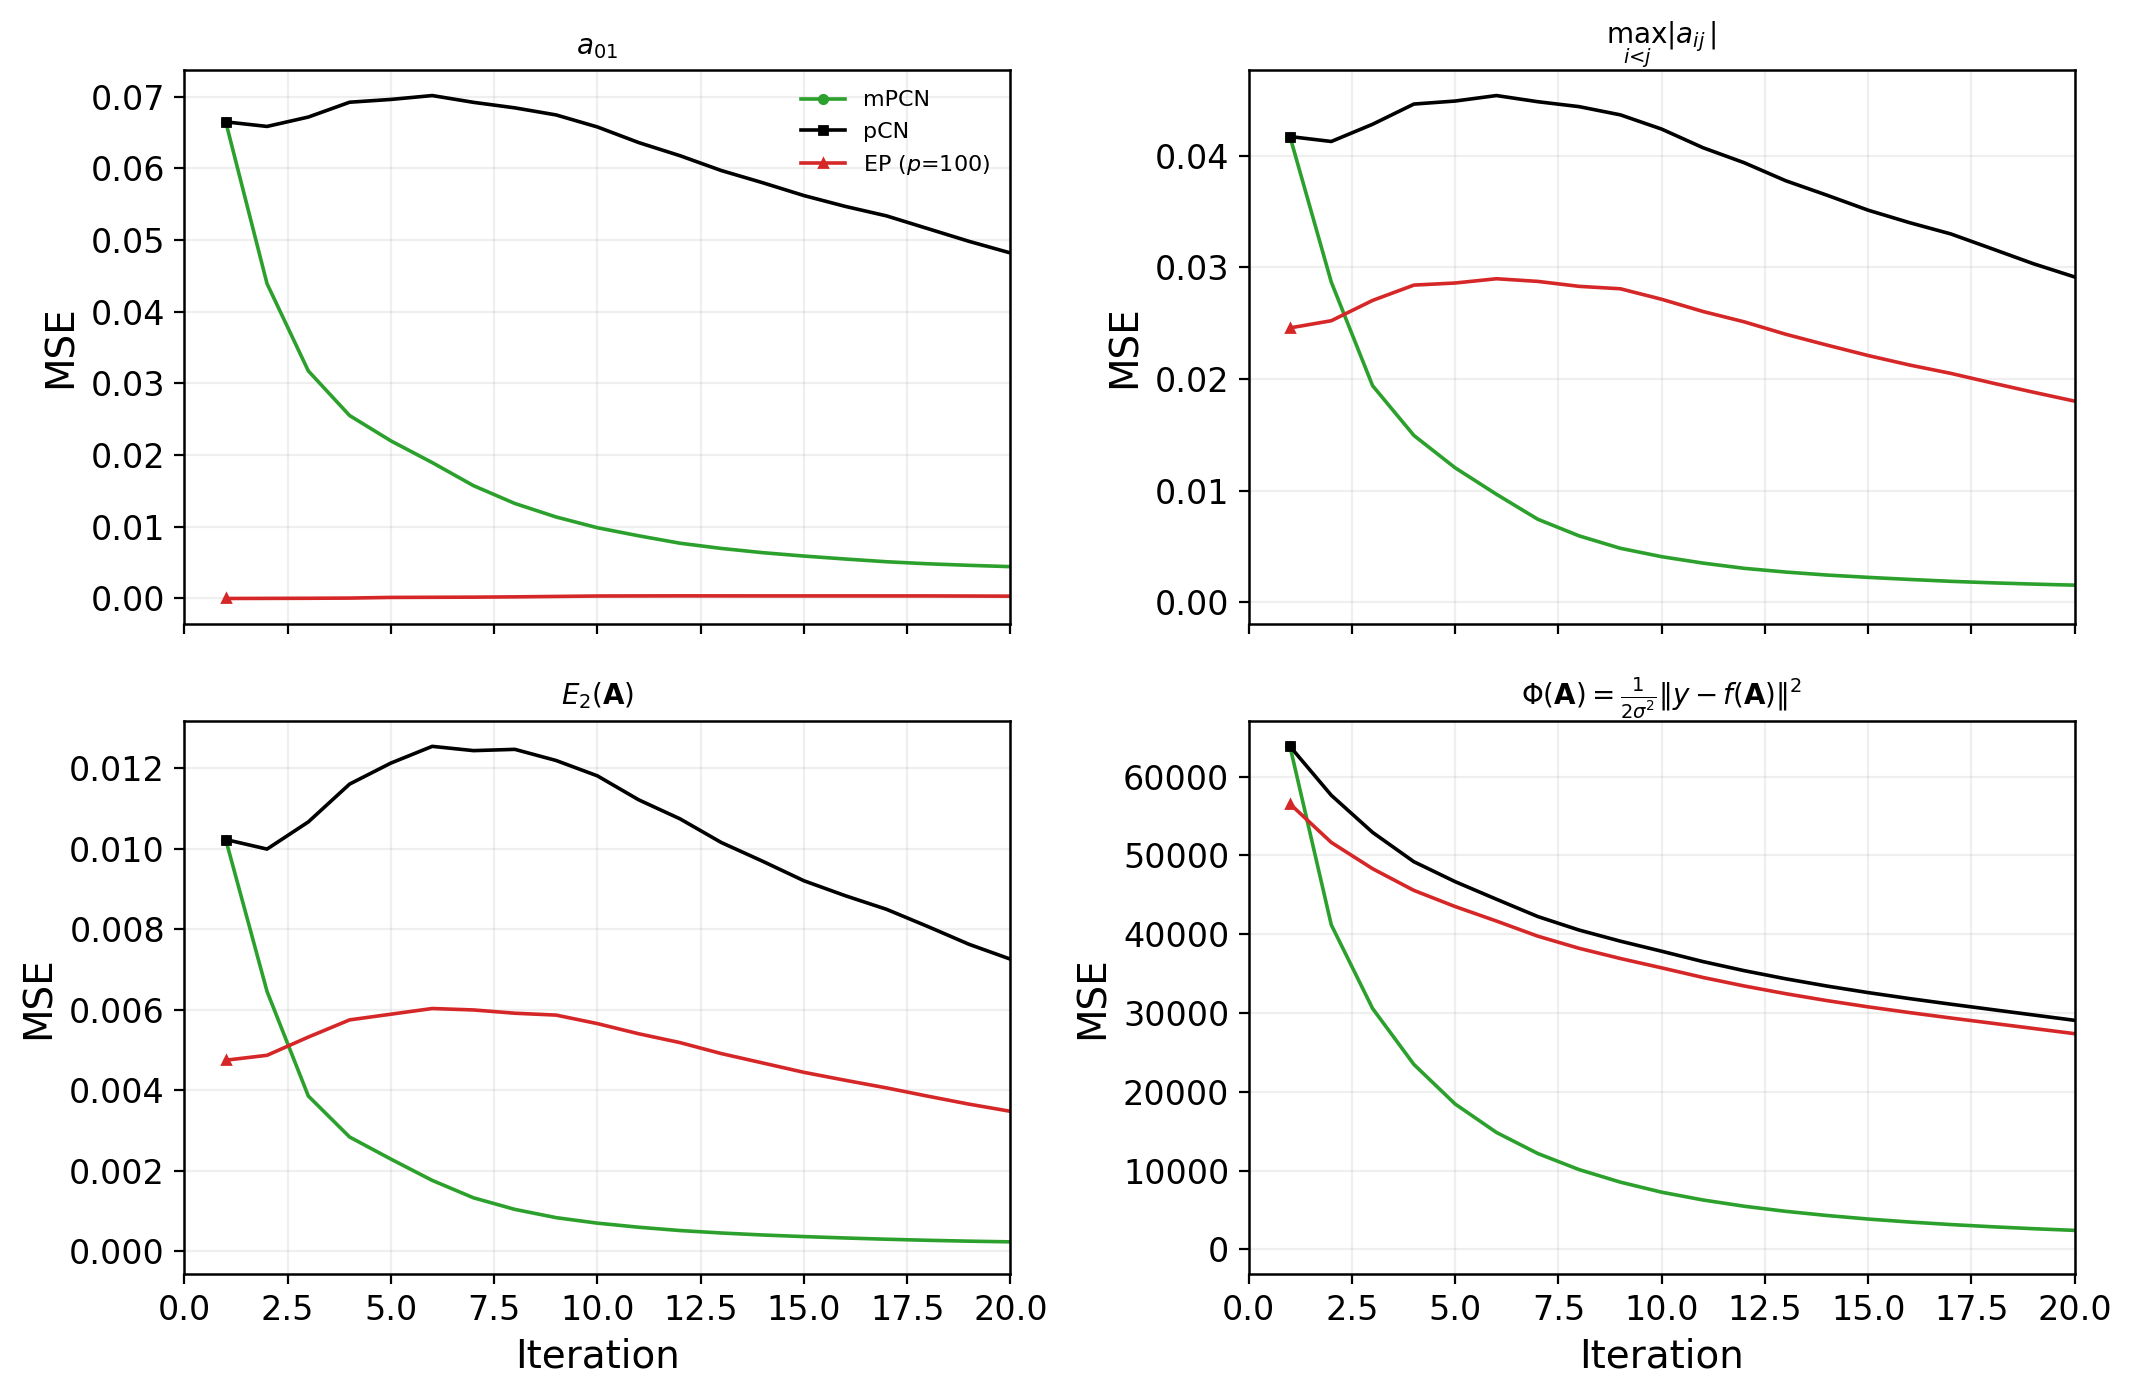

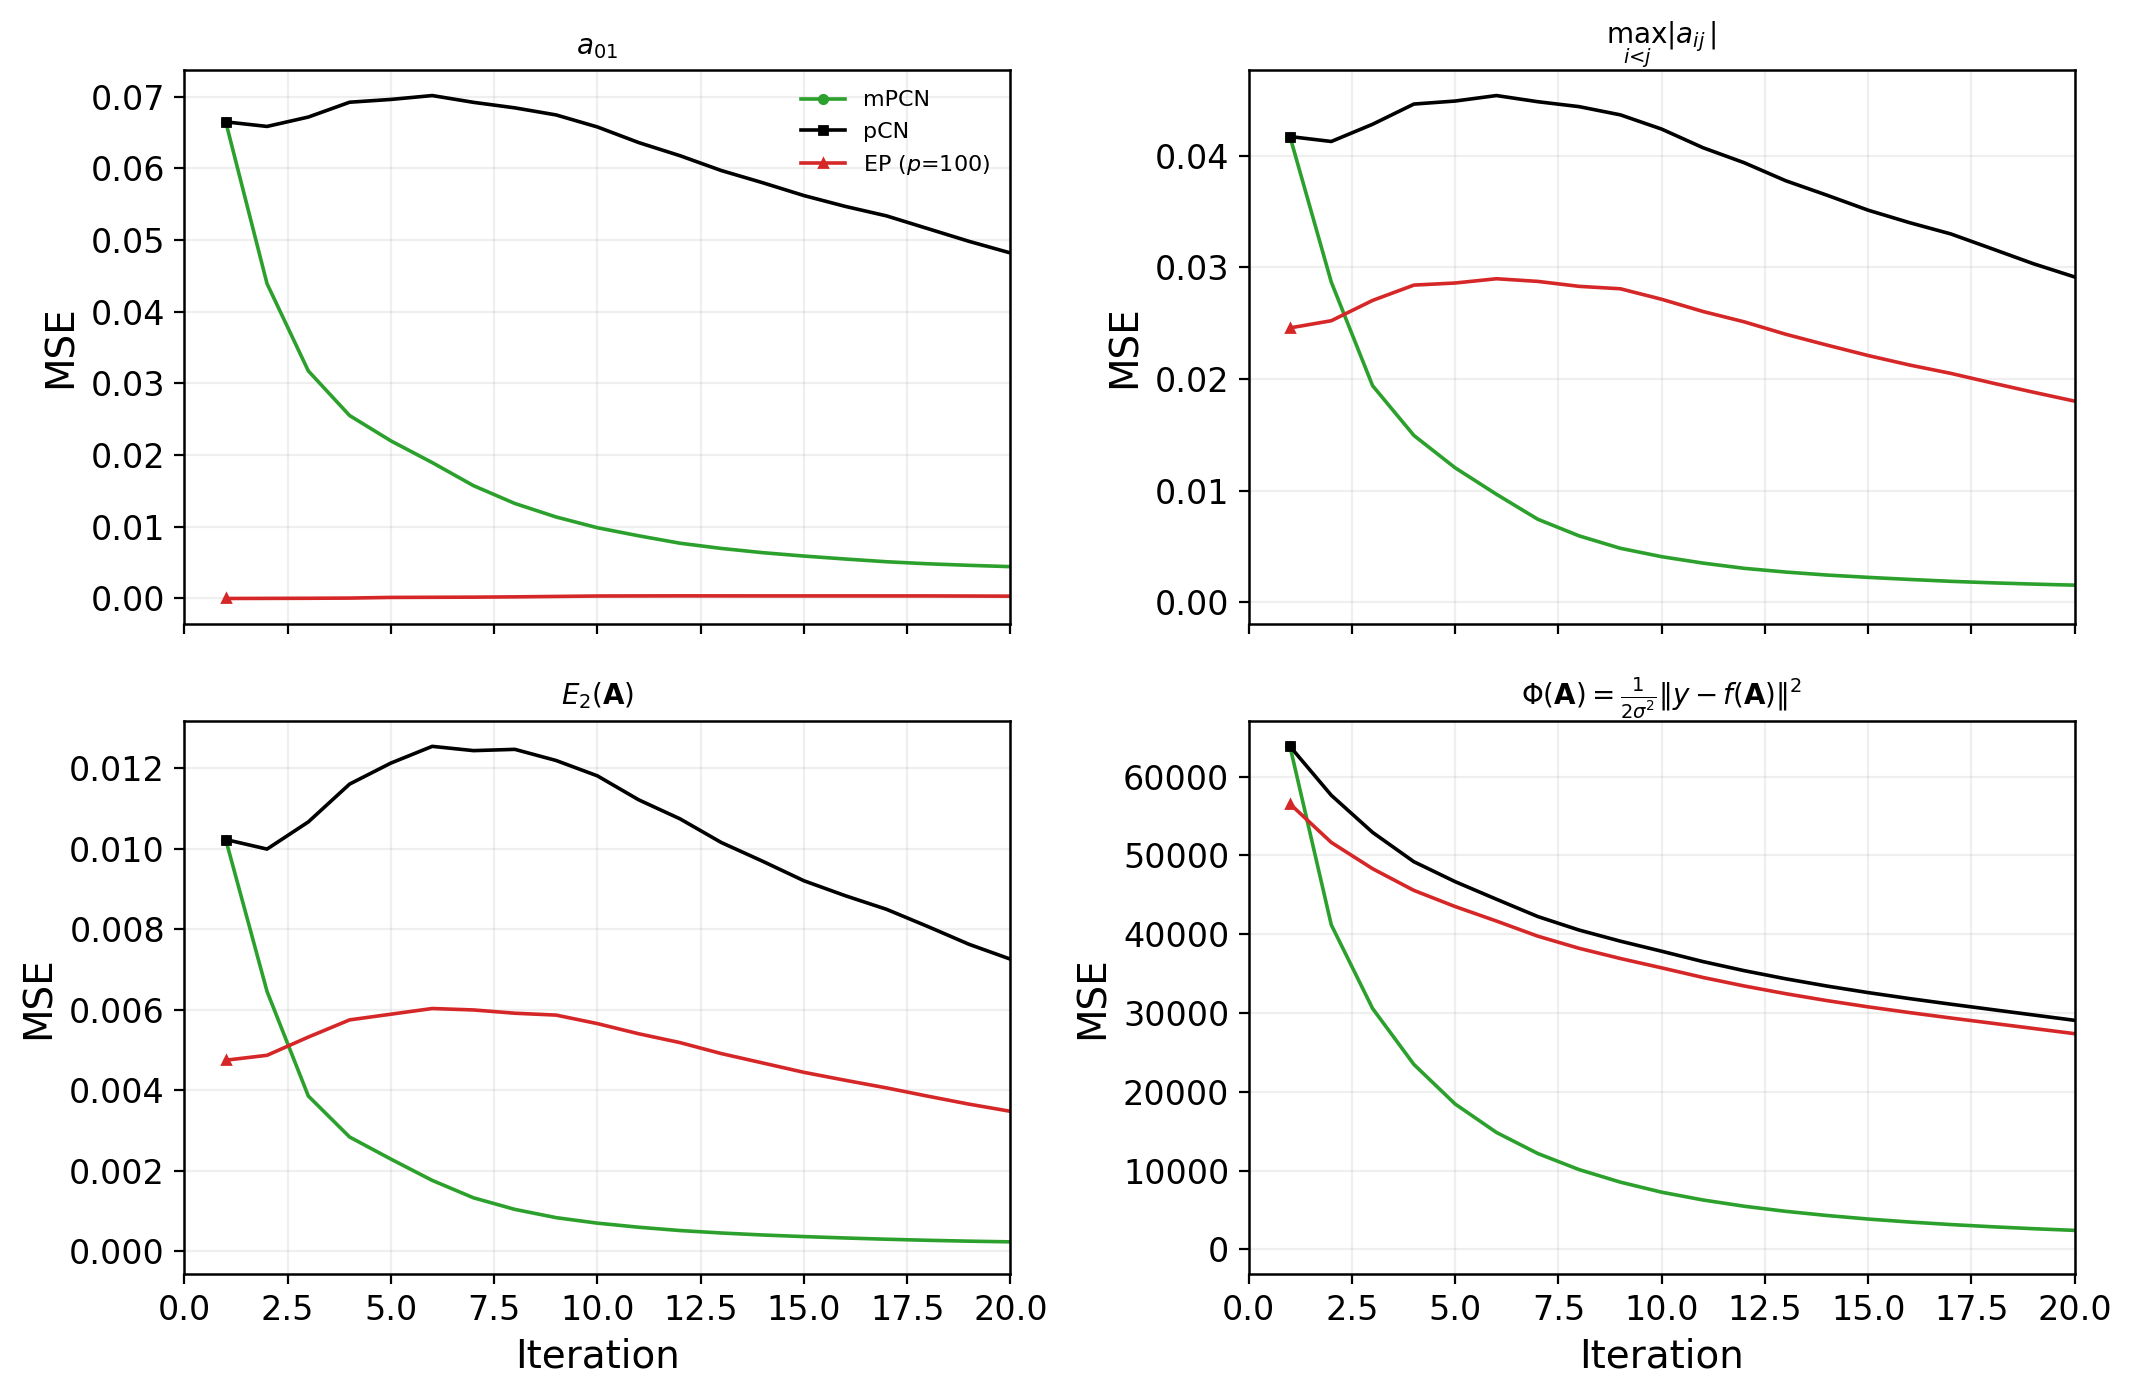

In [30]:
from multiproposal.plotting.solute_transport_convergence import plot_solute_transport_running_mse

# Running MSE: plot the selected publication observables
plot_solute_transport_running_mse(
    mse_results=mse_results,
    plot_defs=mse_target_observables,
    iter_grid=iter_grid,
    reports_dir=reports_dir,
    rho_tag=rho_tag,
    effective_P=effective_P,
    max_xlim=20,
    show=True,
)

## Running MSE: calculation details

This section summarizes the calculations used for the running MSE plots.

**Observables (by ID)**
1. $\bar{x}_{1:d-1}$: mean of the first $d-1$ elements of the parameter vector.
2. $\mathrm{Var}(x_{1:d-1})$: variance of the first $d-1$ elements.
3. $a_{01}$: first component.
4. $\min_i x_i$: minimum over all components.
5. $\bar{x}=\frac{1}{d}\sum_i x_i$: mean over all components.
6. $\mathrm{Var}(x)$: variance over all components.
7. $\|x\|_2$: Euclidean norm.
8. $\Phi(\mathbf{A})=\frac{1}{2\sigma^2}\|y-f(\mathbf{A})\|^2$: potential.

**Running means**
For a chain $\{X_t\}_{t=1}^T$ and observable $\varphi$, the running mean is
$$\bar{\varphi}_t=\frac{1}{t}\sum_{s=1}^t \varphi(X_s).$$
For EP, we first average over the $P$ parallel chains at each iteration,
$$\tilde{\varphi}_t^{\mathrm{EP}}=\frac{1}{P}\sum_{p=1}^P \varphi(X_{t,p}),$$
then compute the running mean over iterations,
$$\bar{\varphi}_t^{\mathrm{EP}}=\frac{1}{t}\sum_{s=1}^t \tilde{\varphi}_s^{\mathrm{EP}}.$$
By linearity, this is equivalent to averaging the per-chain running means at each $t$.

**Reference target**
Targets are posterior means estimated from long mPCN chains after burn-in $10{,}000$:
$$\mu_\varphi=\frac{1}{K}\sum_{k=1}^K \Big(\frac{1}{T-10{,}000}\sum_{t=10{,}001}^T \varphi(X_t^{(k)})\Big).$$

**Running MSE**
At each iteration $t$, the MSE is averaged across chains (or EP groups):
$$\mathrm{MSE}_t=\frac{1}{K}\sum_{k=1}^K\big(\bar{\varphi}_t^{(k)}-\mu_\varphi\big)^2.$$

**Plot selection**
Use the `mse_observable_ids` list in the running-MSE section to control which IDs are shown. The defaults exclude IDs 5 and 6 (mean and variance over all components).

## Pairplots

Posterior pairplots for the solute transport chains (config 2).

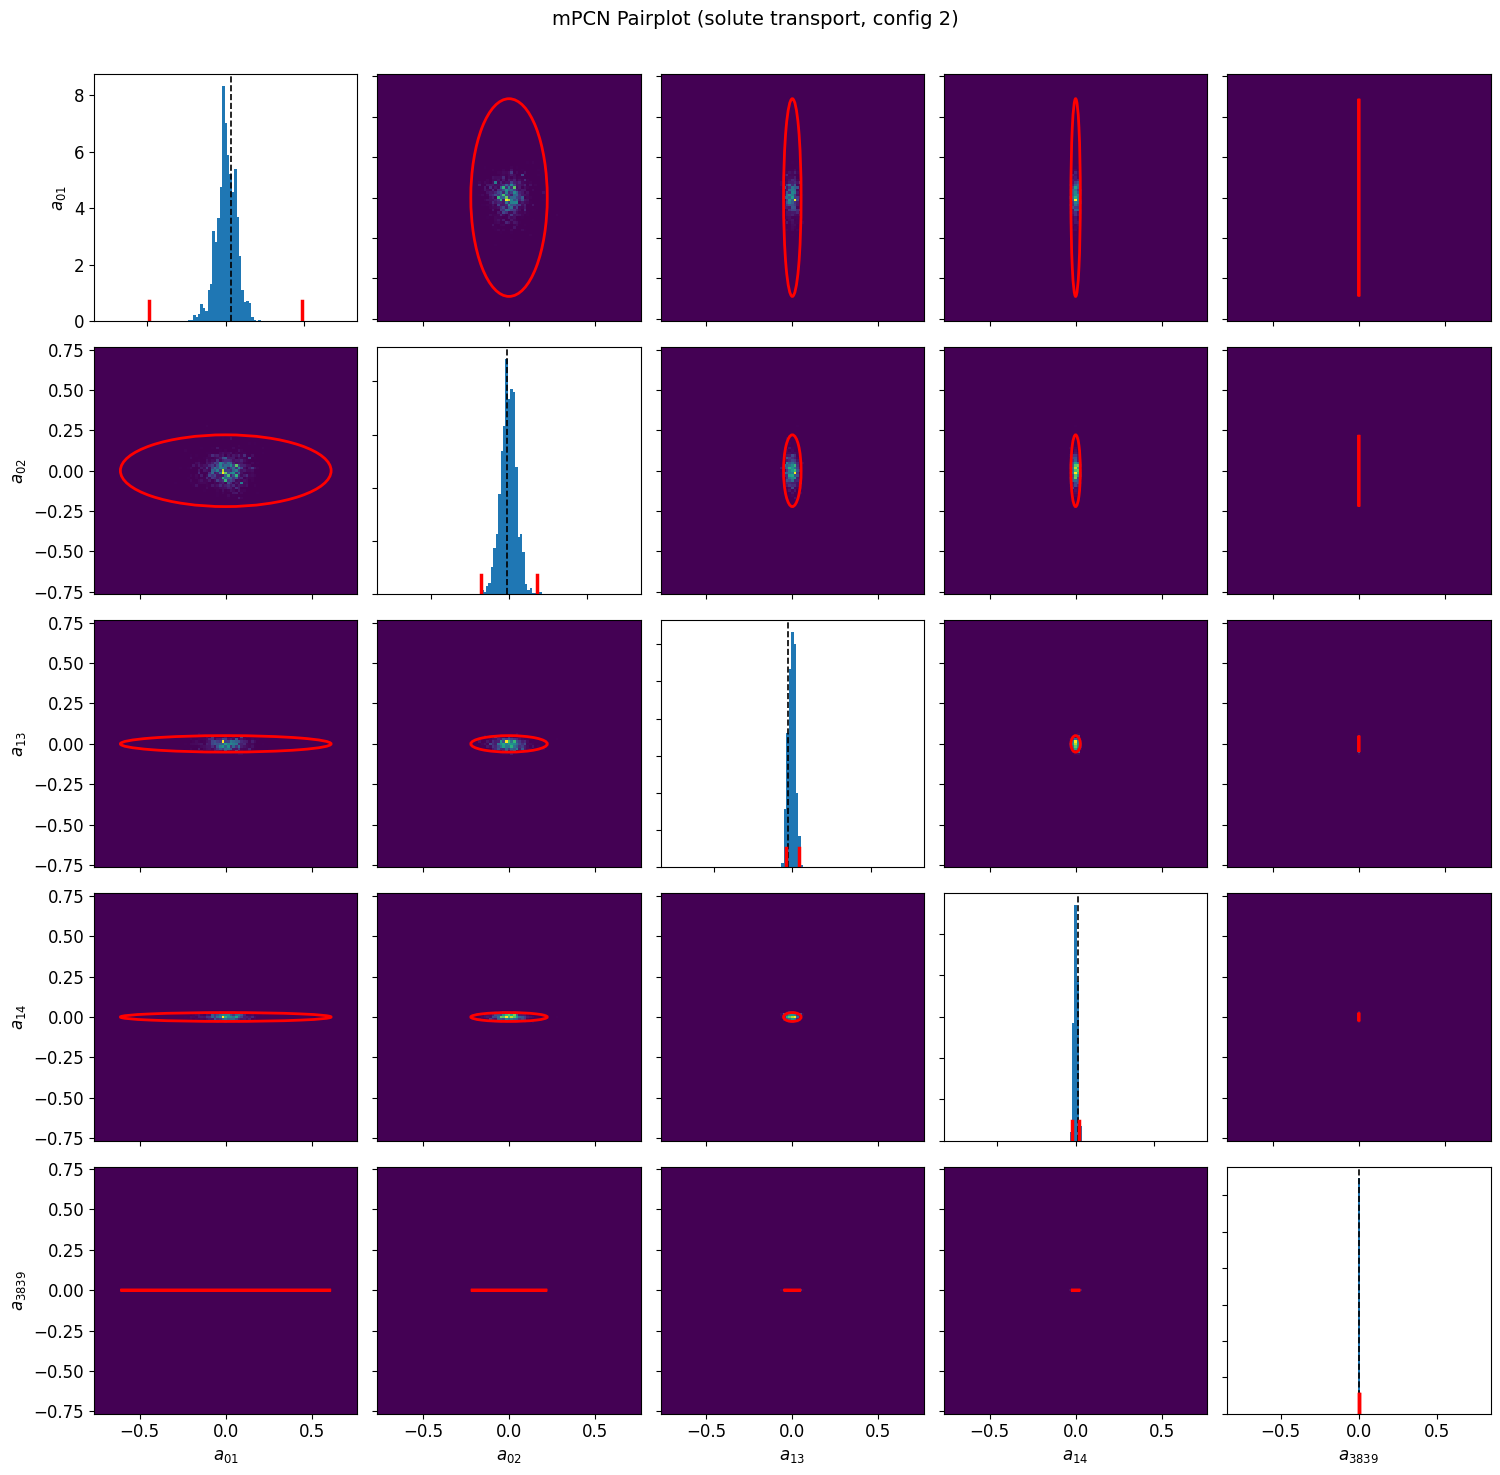

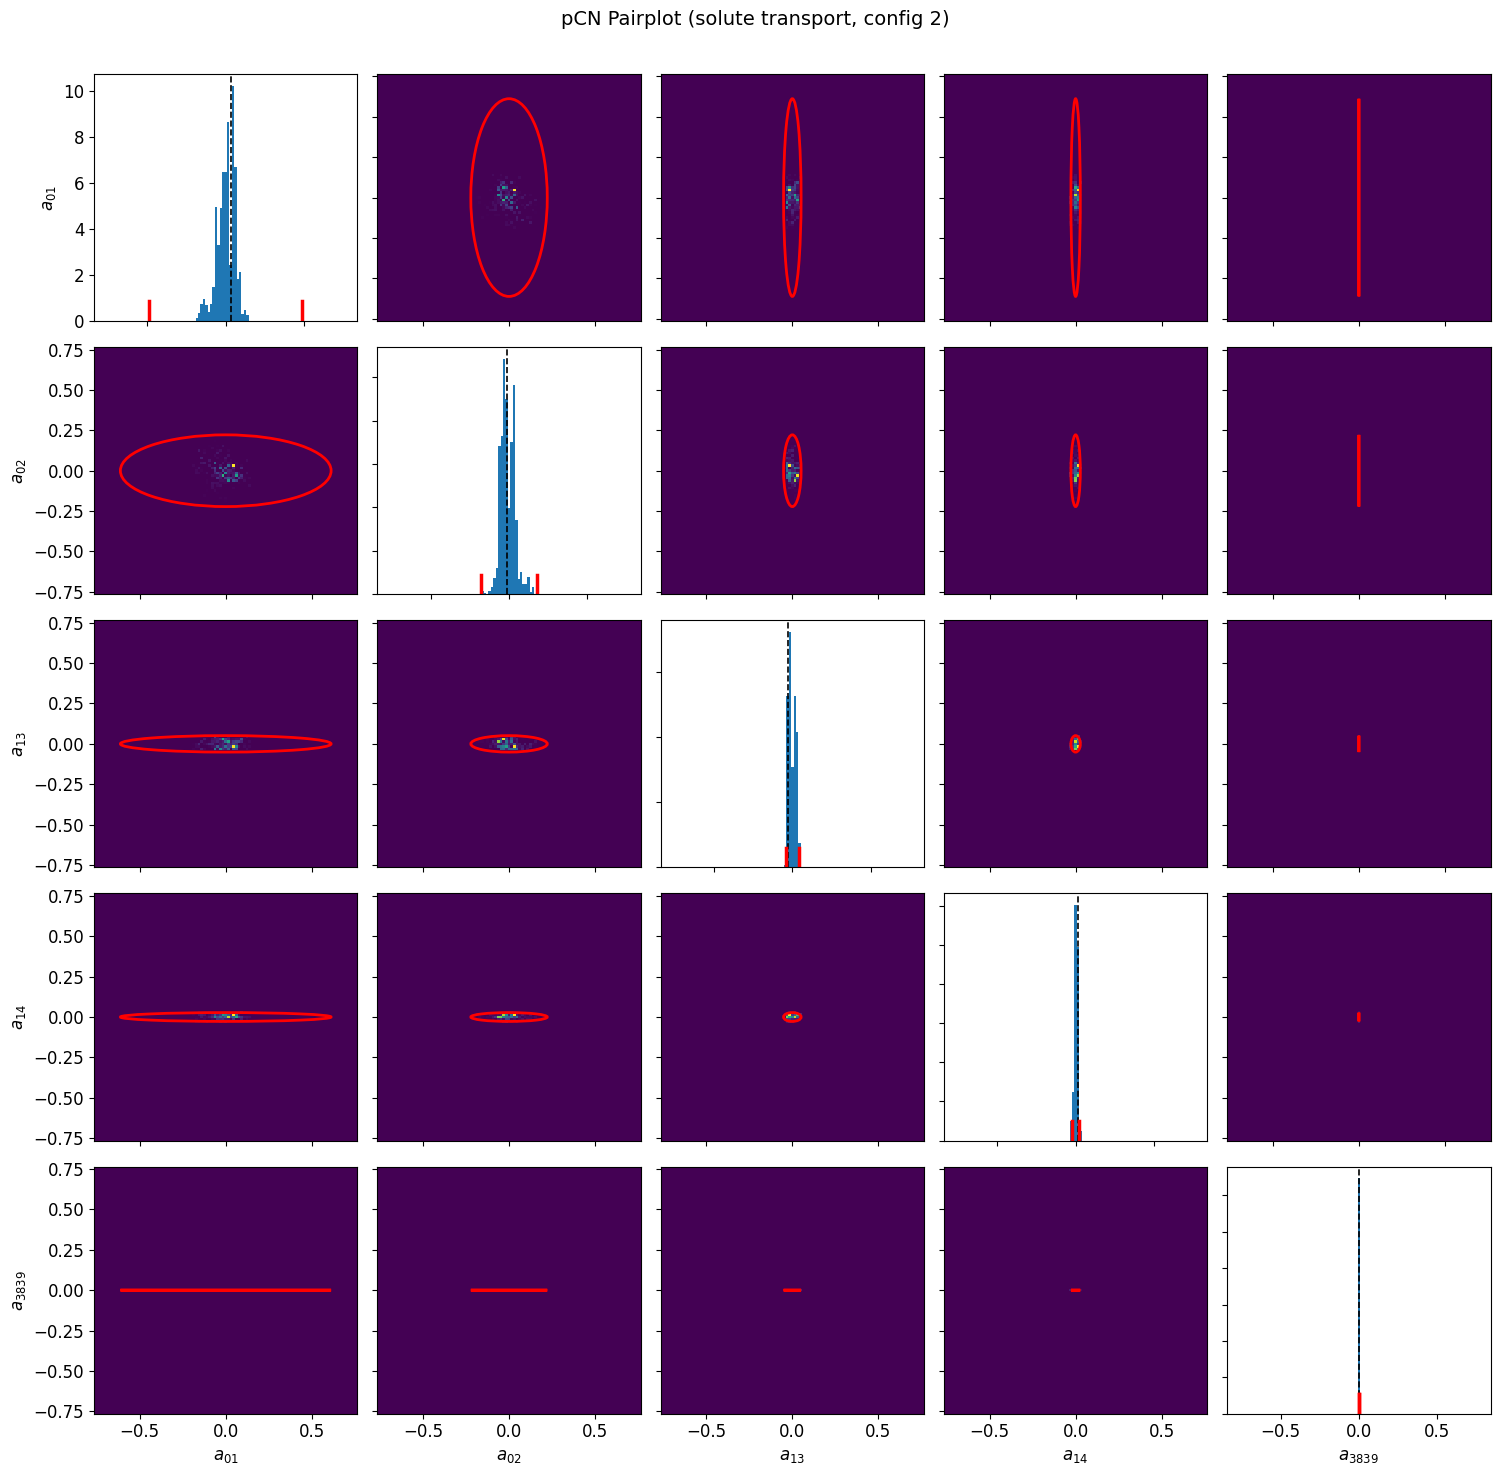

In [15]:
# Pairplots: mPCN vs pCN for selected components
from multiproposal.plotting.diagnostics import make_hist_grid_comps

pairplot_comp_list = [0, 1, 40, 41, 779]
pairplot_burnin = 5000
pairplot_thin = 5

if not mpcn_chains or not pcn_chains:
    raise ValueError("Pairplots require loaded mPCN and pCN chains.")

post_chain_mpcn = mpcn_chains[0]
post_chain_pcn = pcn_chains[0]

max_comp = max(pairplot_comp_list)
if post_chain_mpcn.shape[1] <= max_comp or post_chain_pcn.shape[1] <= max_comp:
    raise ValueError("Pairplot components exceed chain dimension.")

def _thin_chain(chain, burnin, thin):
    if chain.shape[0] <= burnin:
        raise ValueError("burnin exceeds chain length.")
    if thin < 1:
        raise ValueError("thin must be >= 1.")
    return chain[burnin::thin]

post_chain_mpcn = _thin_chain(post_chain_mpcn, pairplot_burnin, pairplot_thin)
# post_chain_pcn = _thin_chain(post_chain_pcn, pairplot_burnin, pairplot_thin)

# Build labels from the packed antisymmetric indices.
param_iju = shared_draws["param_iju"]
param_iju_len = len(param_iju[0])
label_map = {
    comp: f"$a_{{{param_iju[0][comp]}{param_iju[1][comp]}}}$"
    for comp in pairplot_comp_list
    if comp < param_iju_len
}

vals_mpcn = post_chain_mpcn[:, pairplot_comp_list]
vals_pcn = post_chain_pcn[:, pairplot_comp_list]
combined = np.vstack([vals_mpcn, vals_pcn])
max_abs = float(np.max(np.abs(combined))) if combined.size else 1.0
if max_abs == 0.0:
    max_abs = 1.0
R = 1.1 * max_abs
dr = R / 50.0

pairplots_dir = reports_dir / "pairplots"
pairplots_dir.mkdir(parents=True, exist_ok=True)

prior_cov = np.diag(prior_diag)

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=pairplot_comp_list,
    save_path=pairplots_dir / f"solute_transport_pairplot_mpcn_rho{rho_tag}.png",
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f"mPCN Pairplot (solute transport, config {config_id})",
    true_values=data.get("a_true"),
)

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_pcn,
    comp_list=pairplot_comp_list,
    save_path=pairplots_dir / f"solute_transport_pairplot_pcn_rho{rho_tag}.png",
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f"pCN Pairplot (solute transport, config {config_id})",
    true_values=data.get("a_true"),
)